# DSA 8301 - Statistical Inference for Big Data
## Kenya Housing Survey 2023/24: Housing Financial Vulnerability Score (HFVS)

**Student:** Valerie Jerono | **Reg. No.:** 222331  
**Institution:** Strathmore University iLabAfrica  
**Dataset:** Kenya Housing Survey (KHS) 2023/24, KNBS  
**Main output:** A <=50-column inference frame, a transparent five-pillar HFVS score, and report-ready statistical tests.

### Analytical story
Kenya's housing challenge is not only about whether a household has a roof. It is also about whether that household can afford the roof, occupy it securely, survive physical hazards, and access basic utilities. This notebook turns the cleaned KHS master frame into a compact, statistically defensible inference dataset and asks: **which household, dwelling, tenure, hazard, utility, and demographic factors are most strongly associated with housing financial vulnerability?**


## Notebook map and workflow alignment

This notebook follows the project workflow in sequence:

1. **Phase 1 - Load data:** load `master_frame_clean.parquet` from the Colab Drive project folder.
2. **Phase 2 - Reduce columns:** reduce the cleaned 431-column frame to a <=50-column inference frame using pillar coverage, validators, survey weights, and proxy/context variables.
3. **Phase 3 - EDA and normality:** describe variables, visualize distributions, compare groups, and run Shapiro-Wilk normality checks.
4. **Phase 4 - Parametric inference:** t-test, Welch t-test, ANOVA, confidence interval, and multiple regression.
5. **Phase 5 - Nonparametric inference:** Wilcoxon, Mann-Whitney U, Kruskal-Wallis, Spearman correlation, bootstrap intervals, and chi-square validation tests.
6. **Phase 6 - Report assets:** save figures, result tables, column-reduction audit, county atlas, and the reduced frame.

Important design rule from the business understanding document: the inference frame preserves the five HFVS pillars while avoiding an uncontrolled 400+ column analysis. The 50 columns are the **source variables**. Derived HFVS columns are created after reduction so the reduction remains auditable.


In [1]:
# 0.1 Colab setup and dependencies
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
except Exception as exc:
    IN_COLAB = False
    print(f'Colab Drive mount skipped: {exc}')

!pip install -q pyarrow scipy statsmodels scikit-learn


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 0.2 Imports and display settings
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 120)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
RANDOM_STATE = 8301
rng = np.random.default_rng(RANDOM_STATE)

print('Environment ready.')


Environment ready.


In [3]:
# 0.3 Project paths
DRIVE_ROOT = Path('/content/drive/MyDrive/KHS_Dissertation')
BASE = DRIVE_ROOT if DRIVE_ROOT.exists() else Path.cwd()
PQ = BASE / 'data' / 'parquet'
FIGS = BASE / 'outputs' / 'figures' / 'dsa8301'
TABS = BASE / 'outputs' / 'tables' / 'dsa8301'

for folder in [PQ, FIGS, TABS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f'BASE = {BASE}')
print(f'PQ   = {PQ}')
print(f'FIGS = {FIGS}')
print(f'TABS = {TABS}')


BASE = /content/drive/MyDrive/KHS_Dissertation
PQ   = /content/drive/MyDrive/KHS_Dissertation/data/parquet
FIGS = /content/drive/MyDrive/KHS_Dissertation/outputs/figures/dsa8301
TABS = /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301


## 1. Load the cleaned master frame

The cleaning notebook saved `master_frame_clean.parquet` after sentinel decoding, structural-missingness treatment, tenure-stratified imputation, monetary winsorisation, consistency checks, and feature engineering. This notebook starts from that cleaned frame rather than the raw 443-column master.


In [4]:
# 1.1 Load cleaned frame
candidates = [
    PQ / 'master_frame_clean.parquet',
    Path('master_frame_clean.parquet'),
    Path('/content/master_frame_clean.parquet'),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'Could not find master_frame_clean.parquet. Run DSA8301_Phase2_Cleaning_v2.ipynb first, '
        'or place the cleaned parquet in the project data/parquet folder.'
    )

df_raw = pd.read_parquet(DATA_PATH)
print(f'Loaded: {DATA_PATH}')
print(f'Raw cleaned frame: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns')

display(df_raw.head(3))


Loaded: /content/drive/MyDrive/KHS_Dissertation/data/parquet/master_frame_clean.parquet
Raw cleaned frame: 21,347 rows x 431 columns


,hh_id,county_code,urban_rural,water_src_main,c01_1other,water_collect_method,c01_2other,water_treated,water_dist_mins,water_src_secondary,c02_1other,water_collect_secondary,c02_2other,water_secondary_treated,n_toilet_facilities,toilet_type,c04other,has_handwash_facility,n_hh_sharing_toilet,handwash_materials,c07_1,has_bathhouse,waste_coll_county,waste_coll_private,waste_coll_community,waste_coll_self,lighting_src,c10_1,electricity_hrs_day,electricity_conn_type,cooking_fuel,cooking_fuel_n_types,cooking_stove_type,n_cooking_spaces,c12_1_1,cooking_space_indoor,cooking_stove_secondary,c12_3_1,c12_4,owns_radio,owns_mobile,owns_tv,owns_computer,owns_motorcycle,owns_vehicle,owns_fridge,spend_water_kes,spend_electricity_kes,spend_energy_other_kes,hh_tenure_type,dwelling_ownership_doc,ownership_doc_title_deed,ownership_doc_allotment,ownership_doc_agreement,ownership_doc_rent_receipt,ownership_doc_will,ownership_doc_none,n_hh_in_building,shared_facility_water,shared_facility_toilet,...,mean_age_imputed,dependency_ratio_imputed,dw_type_imputed,dw_wall_mat_imputed,dw_roof_mat_imputed,dw_floor_mat_imputed,dw_rooms_imputed,dw_area_m2_imputed,dw_bedrooms_imputed,dw_approved_imputed,dw_has_planning_imputed,dw_in_hazard_zone_imputed,dw_units_count_imputed,lp_n_parcels_imputed,lp_tenure_type_imputed,lp_has_title_imputed,lp_land_use_imputed,lp_has_dispute_imputed,lp_is_registered_imputed,lp_used_as_collateral_imputed,cty_housing_stock_imputed,cty_housing_backlog_imputed,cty_planning_staff_imputed,cty_has_housing_policy_imputed,cty_approval_system_imputed,nema_eia_apps_imputed,nema_eia_approvals_imputed,wsvc_water_conns_imputed,wsvc_sewer_conns_imputed,wsvc_tariff_imputed,wsvc_quality_imputed,wsvc_n_providers_imputed,mort_n_providers_imputed,loan_avg_kes_imputed,loan_outstanding_kes_imputed,loan_n_providers_imputed,fin_portfolio_kes_imputed,fin_n_financiers_imputed,n_toilet_facilities_imputed,cooking_fuel_n_types_imputed,aspire_stay_improve_imputed,aspire_no_change_imputed,l20_a_imputed,l20_b_imputed,l20_c_imputed,flag_owner_with_rent,flag_nonrenter_with_rent,total_exp,rent_burden_ratio,rent_burdened,persons_per_room,is_overcrowded,dw_age_yrs,wall_quality_score,roof_quality_score,floor_quality_score,obj_quality_score,triple_exposed,util_burden_ratio,county_name
0,00-00-55-14,31,2,1.0000,,2.0000,,0,NaN,1.0000,,2.0000,,0,5.0000,7.0000,,0.0000,NaN,1.0000,,1,NaN,NaN,NaN,NaN,1.0000,,NaN,0.0000,7.0000,1.0000,1.0000,2.0000,5.0000,1.0000,1.0000,3.0000,1.0000,0,1,0,0,0,0,0,20000.0000,10000.0000,20000.0000,2,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,8110.0000,NaN,NaN,6.0000,1,0.0000,0.5000,0.5000,0.0000,0.3333,0,1.0000,Laikipia
1,00-01-22-52,14,2,1.0000,,1.0000,,0,NaN,1.0000,,1.0000,,0,5.0000,2.0000,,0.0000,NaN,1.0000,,1,NaN,NaN,NaN,NaN,1.0000,,23.0000,0.0000,7.0000,1.0000,1.0000,2.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1,0,1,0,0,0,0,9000.0000,2000.0000,0.0000,1,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,1,0,1,6750.0000,NaN,NaN,3.0000,1,0.0000,0.5000,0.3300,1.0000,0.6100,0,1.0000,Embu
2,00-02-11-67,38,2,7.0000,,5.0000,,0,30.0000,7.0000,,5.0000,,0,5.0000,7.0000,,0.0000,NaN,4.0000,,1,NaN,NaN,NaN,NaN,1.0000,,NaN,0.0000,9.0000,1.0000,10.0000,2.0000,10.0000,1.0000,1.0000,3.0000,5.0000,0,1,0,0,0,0,0,30000.0000,0.0000,0.0000,1,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,7150.0000,NaN,0.0000,7.0000,1,0.0000,0.2500,0.0000,1.0000,0.4167,0,1.0000,Vihiga


## 2. Reduce 431 columns to 50 or fewer

The reduction is not arbitrary. It keeps:

- identifiers, geography, and survey weights needed for representative summaries;
- direct five-pillar HFVS ingredients;
- validation variables such as stated housing-cost burden and missed payment;
- a small set of demographic proxy/context variables for group comparisons and regression.

Variables that are highly redundant, free-text, administrative, or outside the household-level inference story remain in the cleaning notebook and source parquet, but are not carried into the main inference frame.


In [5]:
# 2.1 A role-audited 50-column source-variable plan
COLUMN_PLAN = [
    # Identifiers, geography, survey design
    ('hh_id', 'identifier', 'Unique household interview key'),
    ('county_code', 'geography', 'County code, 1-47'),
    ('county_name', 'geography', 'County name for reporting'),
    ('urban_rural', 'geography', 'Residence type: 1=Urban, 2=Rural'),
    ('hh_weight', 'survey_design', 'Household survey weight'),

    # Pillar 1 - financial stress
    ('total_exp', 'pillar_1_financial', 'Total monthly expenditure proxy'),
    ('spend_housing_kes', 'pillar_1_financial', 'Monthly housing expenditure'),
    ('rent_actual_kes', 'pillar_1_financial', 'Monthly rent, renter subpopulation'),
    ('rent_burden_ratio', 'pillar_1_financial', 'Rent burden ratio from cleaning notebook'),
    ('rent_burdened', 'pillar_1_financial', 'Rent burden >30 percent threshold'),
    ('housing_cost_burden', 'validator', 'Self-reported housing cost burden'),
    ('missed_payment', 'validator', 'Missed housing payment in past 12 months'),
    ('mort_no_market', 'pillar_1_financial', 'County has no formal mortgage market flag'),

    # Pillar 2 - physical quality
    ('hh_size', 'pillar_2_quality', 'Household size'),
    ('dw_rooms', 'pillar_2_quality', 'Number of dwelling rooms'),
    ('dw_bedrooms', 'pillar_2_quality', 'Number of bedrooms'),
    ('persons_per_room', 'pillar_2_quality', 'Crowding index'),
    ('is_overcrowded', 'pillar_2_quality', 'WHO-style crowding flag, >2 persons per room'),
    ('dw_type', 'pillar_2_quality', 'Dwelling type'),
    ('obj_quality_score', 'pillar_2_quality', 'Objective material quality score'),
    ('perc_overall', 'pillar_2_quality', 'Subjective overall housing perception'),

    # Pillar 3 - tenure security
    ('is_renter', 'pillar_3_tenure', 'Renter flag'),
    ('is_owner', 'pillar_3_tenure', 'Owner flag'),
    ('tenure_type', 'pillar_3_tenure', 'Tenure type'),
    ('has_title_doc', 'pillar_3_tenure', 'Has formal title or ownership document'),
    ('eviction_risk', 'pillar_3_tenure', 'Eviction risk'),
    ('owns_land', 'pillar_3_tenure', 'Owns any land parcel'),
    ('lp_n_parcels', 'pillar_3_tenure', 'Number of land parcels'),
    ('lp_has_title', 'pillar_3_tenure', 'Land parcel has title'),
    ('satisfied_tenure', 'pillar_3_tenure', 'Satisfied with tenure situation'),
    ('yrs_in_dwelling', 'pillar_3_tenure', 'Years or occupancy year in current dwelling'),

    # Pillar 4 - hazard exposure
    ('flood_exposure', 'pillar_4_hazard', 'Flood exposure'),
    ('landslide_exposure', 'pillar_4_hazard', 'Landslide exposure'),
    ('other_hazard_exposure', 'pillar_4_hazard', 'Other environmental hazard exposure'),
    ('dw_in_hazard_zone', 'pillar_4_hazard', 'Dwelling located in hazard-prone zone'),
    ('triple_exposed', 'pillar_4_hazard', 'Flood/informal/no-title compound risk flag'),

    # Pillar 5 - utility deprivation
    ('water_src_main', 'pillar_5_utility', 'Primary water source'),
    ('water_treated', 'pillar_5_utility', 'Water treatment flag'),
    ('water_dist_mins', 'pillar_5_utility', 'Minutes to water source'),
    ('toilet_type', 'pillar_5_utility', 'Toilet type'),
    ('has_handwash_facility', 'pillar_5_utility', 'Handwashing facility flag'),
    ('lighting_src', 'pillar_5_utility', 'Main lighting source'),
    ('cooking_fuel', 'pillar_5_utility', 'Main cooking fuel'),
    ('util_burden_ratio', 'pillar_5_utility', 'Utility burden ratio'),

    # Proxy/context variables for group comparisons and regression
    ('dependency_ratio', 'proxy_context', 'Household dependency ratio'),
    ('mean_age', 'proxy_context', 'Mean household age from roster'),
    ('max_edu_isced', 'proxy_context', 'Maximum education level in household'),
    ('hh_head_sex', 'proxy_context', 'Sex of household head'),
    ('has_disability', 'proxy_context', 'Any household member has disability'),
    ('owns_mobile', 'proxy_context', 'Mobile phone ownership proxy'),
]

assert len(COLUMN_PLAN) == 50, f'Plan should contain exactly 50 source variables, found {len(COLUMN_PLAN)}.'

planned_cols = [c for c, _, _ in COLUMN_PLAN]
present_cols = [c for c in planned_cols if c in df_raw.columns]
missing_cols = [c for c in planned_cols if c not in df_raw.columns]

analysis_50 = df_raw[present_cols].copy()
assert analysis_50.shape[1] <= 50

reduction_audit = pd.DataFrame(COLUMN_PLAN, columns=['column', 'role', 'reason'])
reduction_audit['present'] = reduction_audit['column'].isin(present_cols)
reduction_audit['missing_pct_in_source'] = [
    df_raw[c].isna().mean() * 100 if c in df_raw.columns else np.nan
    for c in reduction_audit['column']
]
reduction_audit['dtype_in_source'] = [
    str(df_raw[c].dtype) if c in df_raw.columns else 'missing'
    for c in reduction_audit['column']
]

print(f'Source columns before reduction : {df_raw.shape[1]:,}')
print(f'Source columns after reduction  : {analysis_50.shape[1]:,}')
print(f'Missing planned columns         : {len(missing_cols)}')
if missing_cols:
    print(missing_cols)

reduction_audit.to_csv(TABS / 'statistical_inference_column_reduction_audit.csv', index=False)
analysis_50.to_parquet(PQ / 'statistical_inference_analysis_frame_50cols.parquet', index=False)
print(f'Saved <=50-column frame -> {PQ / "statistical_inference_analysis_frame_50cols.parquet"}')

display(reduction_audit)


Source columns before reduction : 431
Source columns after reduction  : 50
Missing planned columns         : 0
Saved <=50-column frame -> /content/drive/MyDrive/KHS_Dissertation/data/parquet/statistical_inference_analysis_frame_50cols.parquet


,column,role,reason,present,missing_pct_in_source,dtype_in_source
0,hh_id,identifier,Unique household interview key,True,0.0000,object
1,county_code,geography,"County code, 1-47",True,0.0000,Int64
2,county_name,geography,County name for reporting,True,0.0000,object
3,urban_rural,geography,"Residence type: 1=Urban, 2=Rural",True,0.0000,int8
4,hh_weight,survey_design,Household survey weight,True,0.0000,float64
5,total_exp,pillar_1_financial,Total monthly expenditure proxy,True,0.0000,float64
6,spend_housing_kes,pillar_1_financial,Monthly housing expenditure,True,0.0000,float64
7,rent_actual_kes,pillar_1_financial,"Monthly rent, renter subpopulation",True,67.5271,float64
8,rent_burden_ratio,pillar_1_financial,Rent burden ratio from cleaning notebook,True,97.3064,float64
9,rent_burdened,pillar_1_financial,Rent burden >30 percent threshold,True,78.1093,float64


In [6]:
# 2.2 Role balance and missingness after reduction
role_summary = (
    reduction_audit.query('present')
    .groupby('role', as_index=False)
    .agg(n_columns=('column', 'count'), mean_missing_pct=('missing_pct_in_source', 'mean'))
    .sort_values('role')
)

missing_after_reduction = (
    analysis_50.isna().mean().mul(100).rename('missing_pct')
    .reset_index().rename(columns={'index': 'column'})
    .merge(reduction_audit[['column', 'role', 'reason']], on='column', how='left')
    .sort_values('missing_pct', ascending=False)
)

print('Role balance in <=50-column frame:')
display(role_summary)

print('Highest missingness columns retained, usually structural by design:')
display(missing_after_reduction.head(15))


Role balance in <=50-column frame:


,role,n_columns,mean_missing_pct
0,geography,3,0.0000
1,identifier,1,0.0000
2,pillar_1_financial,6,40.4905
3,pillar_2_quality,8,0.0029
4,pillar_3_tenure,10,0.0019
5,pillar_4_hazard,5,0.0000
6,pillar_5_utility,8,5.8837
7,proxy_context,6,0.0000
8,survey_design,1,0.0000
9,validator,2,0.0539


Highest missingness columns retained, usually structural by design:


,column,missing_pct,role,reason
8,rent_burden_ratio,97.3064,pillar_1_financial,Rent burden ratio from cleaning notebook
9,rent_burdened,78.1093,pillar_1_financial,Rent burden >30 percent threshold
7,rent_actual_kes,67.5271,pillar_1_financial,"Monthly rent, renter subpopulation"
38,water_dist_mins,47.0698,pillar_5_utility,Minutes to water source
10,housing_cost_burden,0.1077,validator,Self-reported housing cost burden
19,obj_quality_score,0.0234,pillar_2_quality,Objective material quality score
29,satisfied_tenure,0.0187,pillar_3_tenure,Satisfied with tenure situation
5,total_exp,0.0000,pillar_1_financial,Total monthly expenditure proxy
1,county_code,0.0000,geography,"County code, 1-47"
0,hh_id,0.0000,identifier,Unique household interview key


## 3. Data quality checks before inference

The cleaning notebook already handled the major issues. This section adds inference-specific guards:

- impossible ages are removed from the analytical `mean_age_clean` field;
- `yrs_in_dwelling` is checked because the output suggests it behaves like a year of occupancy, not elapsed years;
- rent burden is recomputed for the renter subpopulation so the validation tests do not depend on a possibly sparse stored ratio;
- survey weights are cleaned for weighted county summaries.


In [7]:
# 3.1 Helper functions and inference-specific cleaned fields
analysis = analysis_50.copy()


def num(col, frame=analysis):
    if col not in frame.columns:
        return pd.Series(np.nan, index=frame.index, dtype='float64')
    return pd.to_numeric(frame[col], errors='coerce')


def binary01(col, frame=analysis):
    s = num(col, frame)
    return s.where(s.isin([0, 1]))

# Labels for readable figures
analysis['residence_label'] = num('urban_rural').map({1: 'Urban', 2: 'Rural'}).fillna('Unknown')

# Survey weights: keep only positive finite weights; fall back to 1 if absent.
weights = num('hh_weight')
analysis['hh_weight_clean'] = weights.where(np.isfinite(weights) & (weights > 0), 1.0).fillna(1.0)

# Mean age sanity check: values above 110 are not plausible household mean ages.
age = num('mean_age')
analysis['mean_age_clean'] = age.where(age.between(0, 110))

# Tenure duration sanity check: the cleaning output suggests yrs_in_dwelling may behave like
# a calendar year for many rows. If the median is above 150, interpret as occupancy year.
yrs_raw = num('yrs_in_dwelling')
if yrs_raw.notna().sum() and yrs_raw.median() > 150:
    tenure_years = 2024 - yrs_raw
    tenure_interpretation = 'interpreted as occupancy year and converted to duration'
else:
    tenure_years = yrs_raw
    tenure_interpretation = 'interpreted as elapsed years'
analysis['tenure_years_clean'] = tenure_years.where(tenure_years.between(0, 100))

if 'satisfied_tenure' in analysis.columns:
    analysis['satisfied_tenure_clean'] = binary01('satisfied_tenure')
else:
    analysis['satisfied_tenure_clean'] = np.nan

# Recompute rent burden for renters using the documented formula.
is_renter = binary01('is_renter').eq(1)
rent = num('rent_actual_kes')
total_exp = num('total_exp')
housing_exp = num('spend_housing_kes')
denominator = (total_exp - housing_exp).where((total_exp - housing_exp) > 0)
recomputed_ratio = (rent / denominator).where(is_renter & rent.gt(0) & denominator.gt(0))
recomputed_ratio = recomputed_ratio.clip(lower=0, upper=1.5)

stored_ratio = num('rent_burden_ratio')
analysis['rent_burden_ratio_model'] = recomputed_ratio.combine_first(stored_ratio)
analysis['rent_burdened_model'] = (analysis['rent_burden_ratio_model'] > 0.30).astype(float)
analysis.loc[~is_renter | analysis['rent_burden_ratio_model'].isna(), 'rent_burdened_model'] = np.nan

quality_notes = pd.DataFrame({
    'check': [
        'mean_age impossible values removed',
        'rent_burden_ratio non-null before recompute',
        'rent_burden_ratio non-null after recompute',
        'tenure years interpretation',
        'tenure duration impossible values removed',
        'renters in reduced frame',
        'positive survey weights',
    ],
    'value': [
        int(age.notna().sum() - analysis['mean_age_clean'].notna().sum()),
        int(stored_ratio.notna().sum()),
        int(analysis['rent_burden_ratio_model'].notna().sum()),
        tenure_interpretation,
        int(yrs_raw.notna().sum() - analysis['tenure_years_clean'].notna().sum()),
        int(is_renter.sum()),
        int(analysis['hh_weight_clean'].gt(0).sum()),
    ]
})

quality_notes.to_csv(TABS / 'statistical_inference_quality_notes.csv', index=False)
display(quality_notes)


,check,value
0,mean_age impossible values removed,5
1,rent_burden_ratio non-null before recompute,575
2,rent_burden_ratio non-null after recompute,575
3,tenure years interpretation,interpreted as occupancy year and converted to...
4,tenure duration impossible values removed,5948
5,renters in reduced frame,4673
6,positive survey weights,21347


## 4. Construct an interpretable HFVS score

This notebook needs one outcome for inference. The score below is a transparent teaching-score version of the five-pillar HFVS. It is designed for statistical inference and self-discovery, not as a black-box official index.

Scoring convention: **0 = less vulnerable, 1 = more vulnerable**. Each pillar is the mean of available risk components. The final `hfvs_score` is the mean of the five pillar scores.


In [8]:
# 4.1 Risk-score helpers

def norm01(series, invert=False, q_low=0.01, q_high=0.99):
    s = pd.to_numeric(series, errors='coerce').astype(float)
    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)
    lo, hi = s.quantile(q_low), s.quantile(q_high)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        out = pd.Series(np.nan, index=s.index)
    else:
        out = ((s.clip(lo, hi) - lo) / (hi - lo)).clip(0, 1)
    return 1 - out if invert else out


def risk_if_in(col, high_risk_values):
    s = num(col)
    return pd.Series(np.where(s.isin(high_risk_values), 1.0, 0.0), index=analysis.index).where(s.notna())


def risk_if_not_in(col, low_risk_values):
    s = num(col)
    return pd.Series(np.where(s.isin(low_risk_values), 0.0, 1.0), index=analysis.index).where(s.notna())


def risk_binary_yes(col):
    return binary01(col).astype(float)


def risk_binary_no(col):
    s = binary01(col)
    return (1 - s).where(s.notna())


def component_mean(name, components):
    comp = pd.DataFrame({k: v for k, v in components.items() if v is not None})
    comp = comp.dropna(axis=1, how='all')
    if comp.empty:
        analysis[name] = np.nan
        return comp
    analysis[name] = comp.mean(axis=1, skipna=True)
    coverage = comp.notna().mean().rename('coverage_rate').reset_index().rename(columns={'index': 'component'})
    coverage.insert(0, 'pillar', name)
    return coverage

coverage_tables = []

# Pillar 1: financial stress
rent_risk = (num('rent_burden_ratio_model') / 1.5).clip(0, 1)
coverage_tables.append(component_mean('p1_financial_stress', {
    'low_expenditure_risk': norm01(np.log1p(num('total_exp')), invert=True),
    'rent_burden_risk': rent_risk,
    'stated_cost_burden': risk_binary_yes('housing_cost_burden'),
    'missed_payment': risk_binary_yes('missed_payment'),
    'mortgage_market_absent': risk_binary_yes('mort_no_market'),
}))

# Pillar 2: physical quality
perc = num('perc_overall')
subjective_risk = ((perc - 1) / 2).clip(0, 1).where(perc.notna())
coverage_tables.append(component_mean('p2_physical_quality', {
    'poor_objective_quality': (1 - num('obj_quality_score').clip(0, 1)).where(num('obj_quality_score').notna()),
    'crowding_continuous': norm01(num('persons_per_room')),
    'overcrowded_flag': risk_binary_yes('is_overcrowded'),
    'subjective_poor_overall': subjective_risk,
    'dwelling_type_risk_heuristic': norm01(num('dw_type')),
}))

# Pillar 3: tenure security
coverage_tables.append(component_mean('p3_tenure_security', {
    'renter_status': risk_binary_yes('is_renter'),
    'not_owner': risk_binary_no('is_owner'),
    'no_title_doc': risk_binary_no('has_title_doc'),
    'eviction_risk': risk_binary_yes('eviction_risk'),
    'landless': risk_binary_no('owns_land'),
    'land_without_title': risk_binary_no('lp_has_title'),
    'not_satisfied_tenure': risk_binary_no('satisfied_tenure_clean'),
    'short_tenure_duration': norm01(analysis['tenure_years_clean'], invert=True),
}))

# Pillar 4: hazard exposure
coverage_tables.append(component_mean('p4_hazard_exposure', {
    'flood_exposure': norm01(num('flood_exposure')),
    'landslide_exposure': norm01(num('landslide_exposure')),
    'other_hazard_exposure': norm01(num('other_hazard_exposure')),
    'dwelling_hazard_zone': risk_binary_yes('dw_in_hazard_zone'),
    'triple_exposure': risk_binary_yes('triple_exposed'),
}))

# Pillar 5: utility deprivation
# Codebook hypotheses used here: improved water is usually coded as low values; unsafe sanitation often includes 7/8;
# firewood/charcoal are 7/9 in the project notes; grid/solar lighting are treated as lower risk.
coverage_tables.append(component_mean('p5_utility_deprivation', {
    'unimproved_water_source': risk_if_not_in('water_src_main', [1, 2, 3]),
    'water_not_treated': risk_binary_no('water_treated'),
    'long_water_distance': norm01(num('water_dist_mins')),
    'unsafe_toilet_type': risk_if_in('toilet_type', [7, 8]),
    'no_handwash_facility': risk_binary_no('has_handwash_facility'),
    'risky_lighting_source': risk_if_not_in('lighting_src', [1, 2, 3, 4]),
    'solid_cooking_fuel': risk_if_in('cooking_fuel', [7, 9]),
    'utility_burden': num('util_burden_ratio').clip(0, 1),
}))

pillar_cols = [
    'p1_financial_stress',
    'p2_physical_quality',
    'p3_tenure_security',
    'p4_hazard_exposure',
    'p5_utility_deprivation',
]
analysis['hfvs_score'] = analysis[pillar_cols].mean(axis=1, skipna=True)
analysis['hfvs_class'] = pd.cut(
    analysis['hfvs_score'],
    bins=[-0.01, 0.20, 0.40, 0.60, 0.80, 1.00],
    labels=['Very low', 'Low', 'Moderate', 'High', 'Very high']
)
hfvs_qcut = pd.qcut(analysis['hfvs_score'], q=5, duplicates='drop')
analysis['hfvs_quintile'] = hfvs_qcut.astype(str).replace({'nan': np.nan})

component_coverage = pd.concat(coverage_tables, ignore_index=True)
component_coverage.to_csv(TABS / 'statistical_inference_pillar_component_coverage.csv', index=False)

print('HFVS score constructed.')
print(analysis[pillar_cols + ['hfvs_score']].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])
display(component_coverage)


HFVS score constructed.
                            count   mean    std    min    50%    max
p1_financial_stress    21347.0000 0.5280 0.2538 0.0000 0.4276 1.0000
p2_physical_quality    21347.0000 0.4250 0.1615 0.0272 0.4517 0.9000
p3_tenure_security     21347.0000 0.5539 0.1833 0.0000 0.5714 1.0000
p4_hazard_exposure     21347.0000 0.1078 0.1451 0.0000 0.0667 0.8667
p5_utility_deprivation 21347.0000 0.5660 0.1758 0.0075 0.5714 1.0000
hfvs_score             21347.0000 0.4361 0.0878 0.1258 0.4343 0.7682


,pillar,component,coverage_rate
0,p1_financial_stress,low_expenditure_risk,1.0000
1,p1_financial_stress,rent_burden_risk,0.0269
2,p1_financial_stress,stated_cost_burden,0.9989
3,p1_financial_stress,missed_payment,1.0000
4,p1_financial_stress,mortgage_market_absent,1.0000
5,p2_physical_quality,poor_objective_quality,0.9998
6,p2_physical_quality,crowding_continuous,1.0000
7,p2_physical_quality,overcrowded_flag,1.0000
8,p2_physical_quality,subjective_poor_overall,1.0000
9,p2_physical_quality,dwelling_type_risk_heuristic,1.0000


In [9]:
# 4.2 Quick HFVS profile
hfvs_profile = pd.DataFrame({
    'metric': [
        'N households scored', 'Mean HFVS', 'Median HFVS', 'Std HFVS',
        'Share high or very high', 'Share triple exposed', 'Share overcrowded'
    ],
    'value': [
        analysis['hfvs_score'].notna().sum(),
        analysis['hfvs_score'].mean(),
        analysis['hfvs_score'].median(),
        analysis['hfvs_score'].std(),
        analysis['hfvs_class'].isin(['High', 'Very high']).mean(),
        binary01('triple_exposed').mean(),
        binary01('is_overcrowded').mean(),
    ]
})

hfvs_profile.to_csv(TABS / 'statistical_inference_hfvs_profile.csv', index=False)
display(hfvs_profile)

# PyArrow cannot always write pandas Interval-backed columns, especially qcut bins.
# Save a Parquet-safe copy while keeping the in-memory analysis frame unchanged.
parquet_safe = analysis.copy()
for c in parquet_safe.columns:
    if isinstance(parquet_safe[c].dtype, (pd.CategoricalDtype, pd.IntervalDtype)):
        parquet_safe[c] = parquet_safe[c].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

parquet_safe.to_parquet(PQ / 'statistical_inference_scored_frame.parquet', index=False)
print(f'Scored analysis frame saved -> {PQ / "statistical_inference_scored_frame.parquet"}')


,metric,value
0,N households scored,21347.0000
1,Mean HFVS,0.4361
2,Median HFVS,0.4343
3,Std HFVS,0.0878
4,Share high or very high,0.0333
5,Share triple exposed,0.0549
6,Share overcrowded,0.5649


Scored analysis frame saved -> /content/drive/MyDrive/KHS_Dissertation/data/parquet/statistical_inference_scored_frame.parquet


### What the HFVS profile means for modelling

The scored data support a **continuous vulnerability model**, not a first-pass binary classifier. The mean HFVS is about **0.436**, the median is about **0.434**, and only about **3.3%** of households fall into the high or very-high class. If we immediately turn HFVS into a high-risk/not-high-risk target, we throw away most of the ranking information and create a severe class-imbalance problem.

The profile also shows why single-indicator modelling is too thin: only **5.5%** of households are triple-exposed, but **56.5%** are overcrowded. A good model must therefore preserve broad continuous gradients such as crowding and expenditure while also retaining categorical structure such as tenure, title status, water source, toilet type, fuel type, and hazard flags.


## 5. Exploratory data analysis

EDA answers three practical questions before hypothesis testing:

1. What does vulnerability look like overall?
2. Which pillars appear to drive the score?
3. Do key relationships differ by urban/rural residence, tenure, hazard exposure, or deprivation?


In [10]:
# 5.1 Descriptive statistics table
key_numeric = [
    'hfvs_score',
    'p1_financial_stress', 'p2_physical_quality', 'p3_tenure_security',
    'p4_hazard_exposure', 'p5_utility_deprivation',
    'total_exp', 'rent_burden_ratio_model', 'persons_per_room',
    'obj_quality_score', 'util_burden_ratio', 'dependency_ratio',
    'mean_age_clean', 'hh_size', 'tenure_years_clean'
]
key_numeric = [c for c in key_numeric if c in analysis.columns]

def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

def span(x):
    return x.max() - x.min()

desc = analysis[key_numeric].agg(['count', 'mean', 'median', 'std', 'var', span, iqr]).T
desc.columns = ['N', 'Mean', 'Median', 'Std Dev', 'Variance', 'Range', 'IQR']
desc.to_csv(TABS / 'statistical_inference_descriptive_statistics.csv')

display(desc)


,N,Mean,Median,Std Dev,Variance,Range,IQR
hfvs_score,21347.0000,0.4361,0.4343,0.0878,0.0077,0.6424,0.1217
p1_financial_stress,21347.0000,0.5280,0.4276,0.2538,0.0644,1.0000,0.4527
p2_physical_quality,21347.0000,0.4250,0.4517,0.1615,0.0261,0.8728,0.2632
p3_tenure_security,21347.0000,0.5539,0.5714,0.1833,0.0336,1.0000,0.2857
p4_hazard_exposure,21347.0000,0.1078,0.0667,0.1451,0.0210,0.8667,0.1333
p5_utility_deprivation,21347.0000,0.5660,0.5714,0.1758,0.0309,0.9925,0.2733
total_exp,21347.0000,29670.7159,16400.0000,37159.1377,1380801516.0898,352989.0000,23908.0000
rent_burden_ratio_model,575.0000,0.3652,0.2333,0.3869,0.1497,1.4953,0.3588
persons_per_room,21347.0000,3.1600,3.0000,2.1626,4.6768,14.5000,2.5000
obj_quality_score,21342.0000,0.4762,0.5267,0.1882,0.0354,1.0000,0.2233


In [11]:
# 5.2 Weighted and unweighted HFVS by residence

def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors='coerce')
    weights = pd.to_numeric(weights, errors='coerce')
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

residence_summary = []
for label, g in analysis.groupby('residence_label', dropna=False):
    residence_summary.append({
        'residence': label,
        'n': len(g),
        'mean_hfvs_unweighted': g['hfvs_score'].mean(),
        'mean_hfvs_weighted': weighted_mean(g['hfvs_score'], g['hh_weight_clean']),
        'median_total_exp': g['total_exp'].median(),
        'pct_overcrowded': binary01('is_overcrowded', g).mean(),
        'pct_triple_exposed': binary01('triple_exposed', g).mean(),
    })
residence_summary = pd.DataFrame(residence_summary)
residence_summary.to_csv(TABS / 'statistical_inference_residence_summary.csv', index=False)

display(residence_summary)


,residence,n,mean_hfvs_unweighted,mean_hfvs_weighted,median_total_exp,pct_overcrowded,pct_triple_exposed
0,Rural,9447,0.4197,0.3949,10100.0000,0.4886,0.0674
1,Urban,11900,0.4491,0.4419,26200.0000,0.6255,0.0450


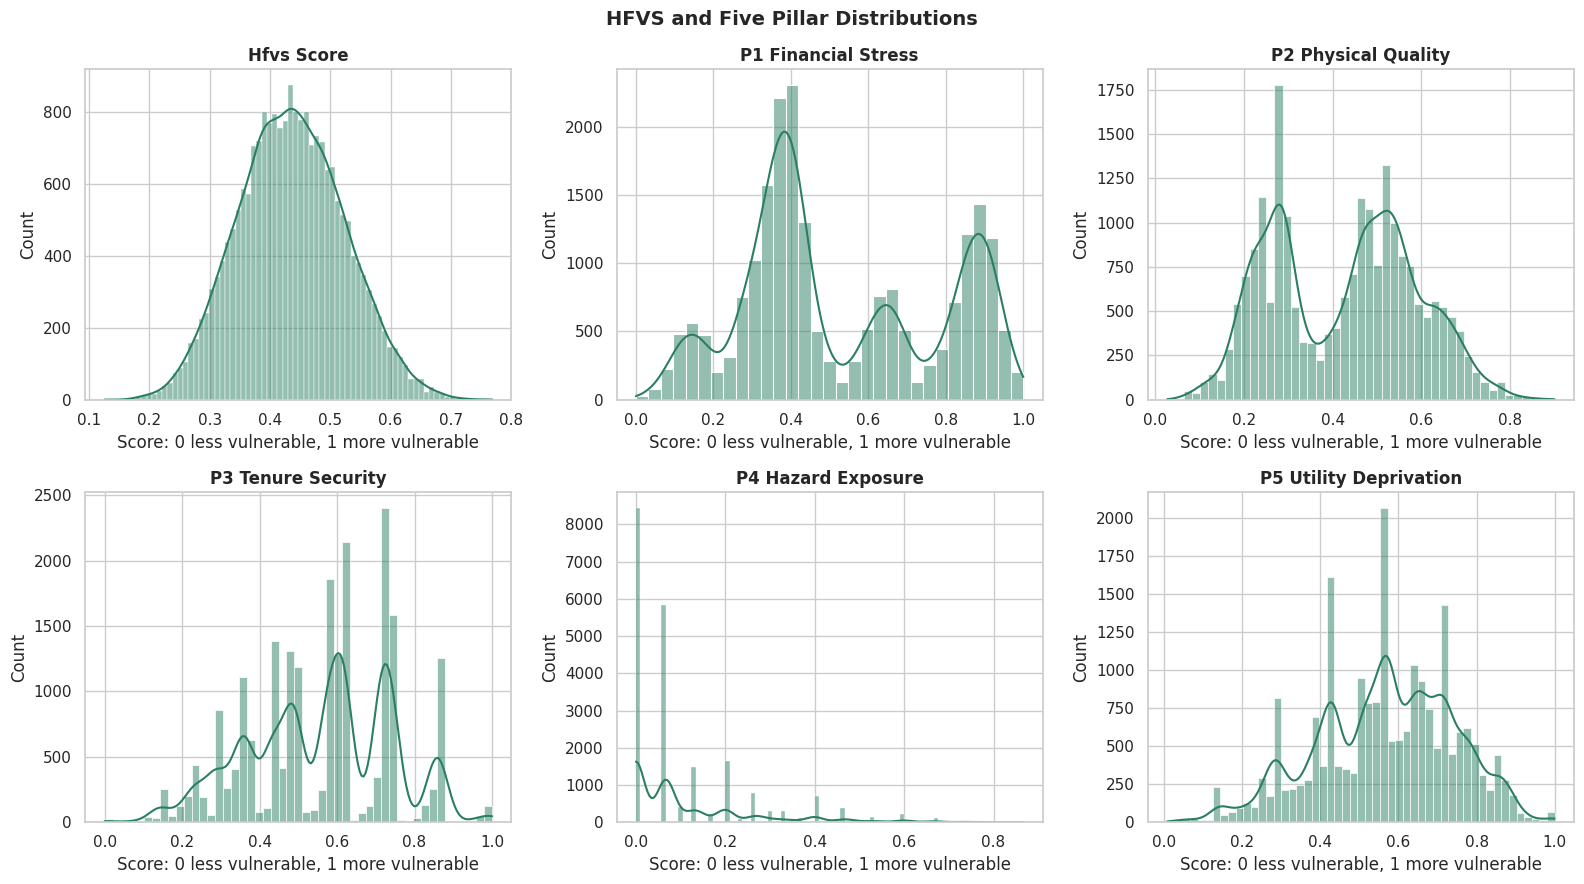

In [12]:
# 5.3 Distribution plots for HFVS and pillars
plot_cols = ['hfvs_score'] + pillar_cols
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    sns.histplot(analysis[col].dropna(), kde=True, ax=ax, color='#2A7F62')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Score: 0 less vulnerable, 1 more vulnerable')

for ax in axes[len(plot_cols):]:
    ax.axis('off')

fig.suptitle('HFVS and Five Pillar Distributions', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_hfvs_pillar_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


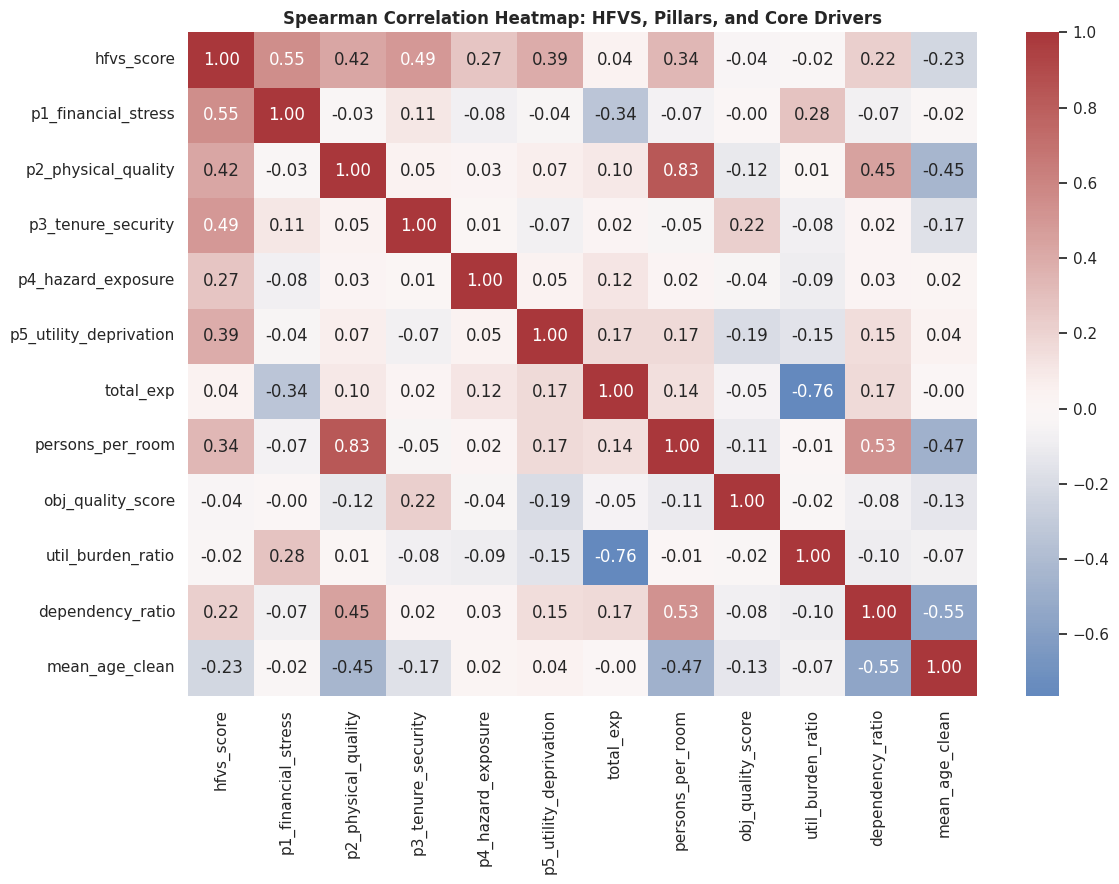

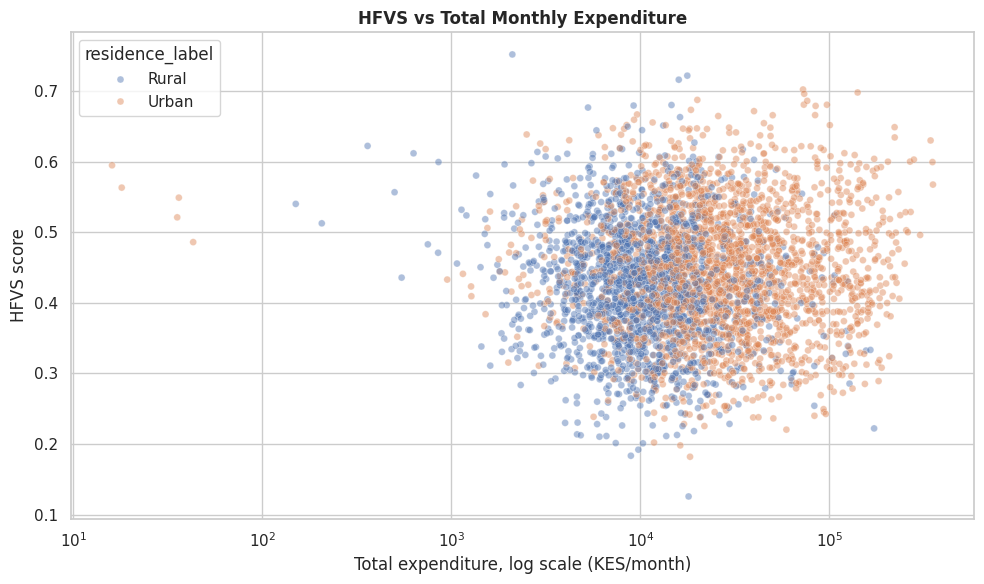

In [13]:
# 5.4 Relationship heatmap and key scatter plot
corr_cols = [
    'hfvs_score', 'p1_financial_stress', 'p2_physical_quality', 'p3_tenure_security',
    'p4_hazard_exposure', 'p5_utility_deprivation', 'total_exp', 'persons_per_room',
    'obj_quality_score', 'util_burden_ratio', 'dependency_ratio', 'mean_age_clean'
]
corr_cols = [c for c in corr_cols if c in analysis.columns]

corr = analysis[corr_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Spearman Correlation Heatmap: HFVS, Pillars, and Core Drivers')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

sample = analysis.dropna(subset=['total_exp', 'hfvs_score']).sample(
    n=min(4000, analysis.dropna(subset=['total_exp', 'hfvs_score']).shape[0]),
    random_state=RANDOM_STATE
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=sample, x='total_exp', y='hfvs_score', hue='residence_label', alpha=0.45, s=25, ax=ax)
ax.set_xscale('log')
ax.set_title('HFVS vs Total Monthly Expenditure')
ax.set_xlabel('Total expenditure, log scale (KES/month)')
ax.set_ylabel('HFVS score')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_hfvs_vs_expenditure.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# 5.5 Objective-subjective quality gap
# perc_overall is interpreted as 1=good, 2=fair, 3=poor based on the project reference notes.
perc = num('perc_overall')
analysis['subjective_quality_risk'] = ((perc - 1) / 2).clip(0, 1).where(perc.notna())
analysis['objective_quality_risk'] = 1 - num('obj_quality_score').clip(0, 1)
analysis['quality_gap'] = analysis['objective_quality_risk'] - analysis['subjective_quality_risk']
analysis['latent_quality_risk'] = (analysis['quality_gap'] > 0.30).astype(float).where(analysis['quality_gap'].notna())

gap_summary = analysis[['objective_quality_risk', 'subjective_quality_risk', 'quality_gap', 'latent_quality_risk']].describe().T
print('Quality gap: positive values mean objective conditions are worse than self-perception suggests.')
display(gap_summary)

county_gap = (
    analysis.groupby(['county_code', 'county_name'], dropna=False)
    .agg(n=('hfvs_score', 'size'), mean_quality_gap=('quality_gap', 'mean'), pct_latent_risk=('latent_quality_risk', 'mean'))
    .reset_index()
    .query('n >= 50')
    .sort_values('pct_latent_risk', ascending=False)
)
county_gap.to_csv(TABS / 'statistical_inference_quality_gap_by_county.csv', index=False)

print('Top counties by latent objective quality risk:')
display(county_gap.head(12))


Quality gap: positive values mean objective conditions are worse than self-perception suggests.


,count,mean,std,min,25%,50%,75%,max
objective_quality_risk,21342.0000,0.5238,0.1882,0.0000,0.3600,0.4733,0.5833,1.0000
subjective_quality_risk,21347.0000,0.4595,0.1483,0.0000,0.5000,0.5000,0.5000,1.0000
quality_gap,21342.0000,0.0643,0.2478,-0.7233,-0.1400,0.0567,0.1667,1.0000
latent_quality_risk,21342.0000,0.1782,0.3827,0.0000,0.0000,0.0000,0.0000,1.0000


Top counties by latent objective quality risk:


,county_code,county_name,n,mean_quality_gap,pct_latent_risk
5,6,Taita-Taveta,405,0.3835,0.6716
20,21,Murang'a,355,0.3502,0.6366
31,32,Nakuru,686,0.2535,0.4883
17,18,Nyandarua,382,0.2354,0.4162
18,19,Nyeri,434,0.1993,0.3917
12,13,Tharaka-Nithi,455,0.1682,0.3253
19,20,Kirinyaga,450,0.2006,0.3178
21,22,Kiambu,319,0.1507,0.3072
4,5,Lamu,361,0.0948,0.2853
35,36,Bomet,422,0.1324,0.2844


## 6. Normality decision gate

The workflow requires normality checks before choosing tests. With more than 21,000 observations, Shapiro-Wilk can reject even tiny deviations, so the table includes skewness and kurtosis as practical context. The decision rule remains: **Shapiro p > 0.05 suggests approximate normality; p <= 0.05 points us toward nonparametric alternatives.**


In [15]:
# 6.1 Shapiro-Wilk normality assessment
normality_cols = [
    'hfvs_score', 'p1_financial_stress', 'p2_physical_quality', 'p3_tenure_security',
    'p4_hazard_exposure', 'p5_utility_deprivation', 'total_exp', 'persons_per_room',
    'obj_quality_score', 'util_burden_ratio', 'dependency_ratio', 'mean_age_clean'
]
normality_cols = [c for c in normality_cols if c in analysis.columns]

normality_rows = []
for col in normality_cols:
    x = pd.to_numeric(analysis[col], errors='coerce').dropna()
    if len(x) < 3:
        continue
    sample = x.sample(n=min(5000, len(x)), random_state=RANDOM_STATE)
    stat, p = stats.shapiro(sample)
    normality_rows.append({
        'variable': col,
        'n_nonmissing': len(x),
        'sample_used': len(sample),
        'shapiro_W': stat,
        'p_value': p,
        'skew': stats.skew(x, nan_policy='omit'),
        'kurtosis': stats.kurtosis(x, nan_policy='omit'),
        'normal_at_0_05': 'Yes' if p > 0.05 else 'No',
        'recommended_family': 'Parametric acceptable' if p > 0.05 else 'Use nonparametric / robust checks',
    })

normality = pd.DataFrame(normality_rows).sort_values('p_value')
normality.to_csv(TABS / 'statistical_inference_normality_results.csv', index=False)
display(normality)


,variable,n_nonmissing,sample_used,shapiro_W,p_value,skew,kurtosis,normal_at_0_05,recommended_family
6,total_exp,21347,5000,0.6520,0.0000,2.9627,10.9377,No,Use nonparametric / robust checks
4,p4_hazard_exposure,21347,5000,0.7392,0.0000,1.8339,3.2076,No,Use nonparametric / robust checks
10,dependency_ratio,21347,5000,0.7947,0.0000,2.0548,6.5999,No,Use nonparametric / robust checks
9,util_burden_ratio,21347,5000,0.8368,0.0000,-0.1552,-1.6149,No,Use nonparametric / robust checks
8,obj_quality_score,21342,5000,0.8490,0.0000,-0.9897,0.2941,No,Use nonparametric / robust checks
11,mean_age_clean,21342,5000,0.8597,0.0000,1.5386,2.3475,No,Use nonparametric / robust checks
7,persons_per_room,21347,5000,0.9066,0.0000,1.0736,1.2459,No,Use nonparametric / robust checks
1,p1_financial_stress,21347,5000,0.9226,0.0000,0.2638,-1.1694,No,Use nonparametric / robust checks
2,p2_physical_quality,21347,5000,0.9633,0.0000,0.0414,-1.0168,No,Use nonparametric / robust checks
3,p3_tenure_security,21347,5000,0.9809,0.0000,-0.1577,-0.5386,No,Use nonparametric / robust checks


### Normality implication

Every tested variable rejects Shapiro-Wilk normality at alpha = 0.05. HFVS itself is close to symmetric, but it is bounded between 0 and 1 and the large sample makes even small deviations statistically detectable. This means ordinary least squares is useful as a transparent baseline, but the main model should be robust to a bounded, non-Gaussian response and to mixed variable types.


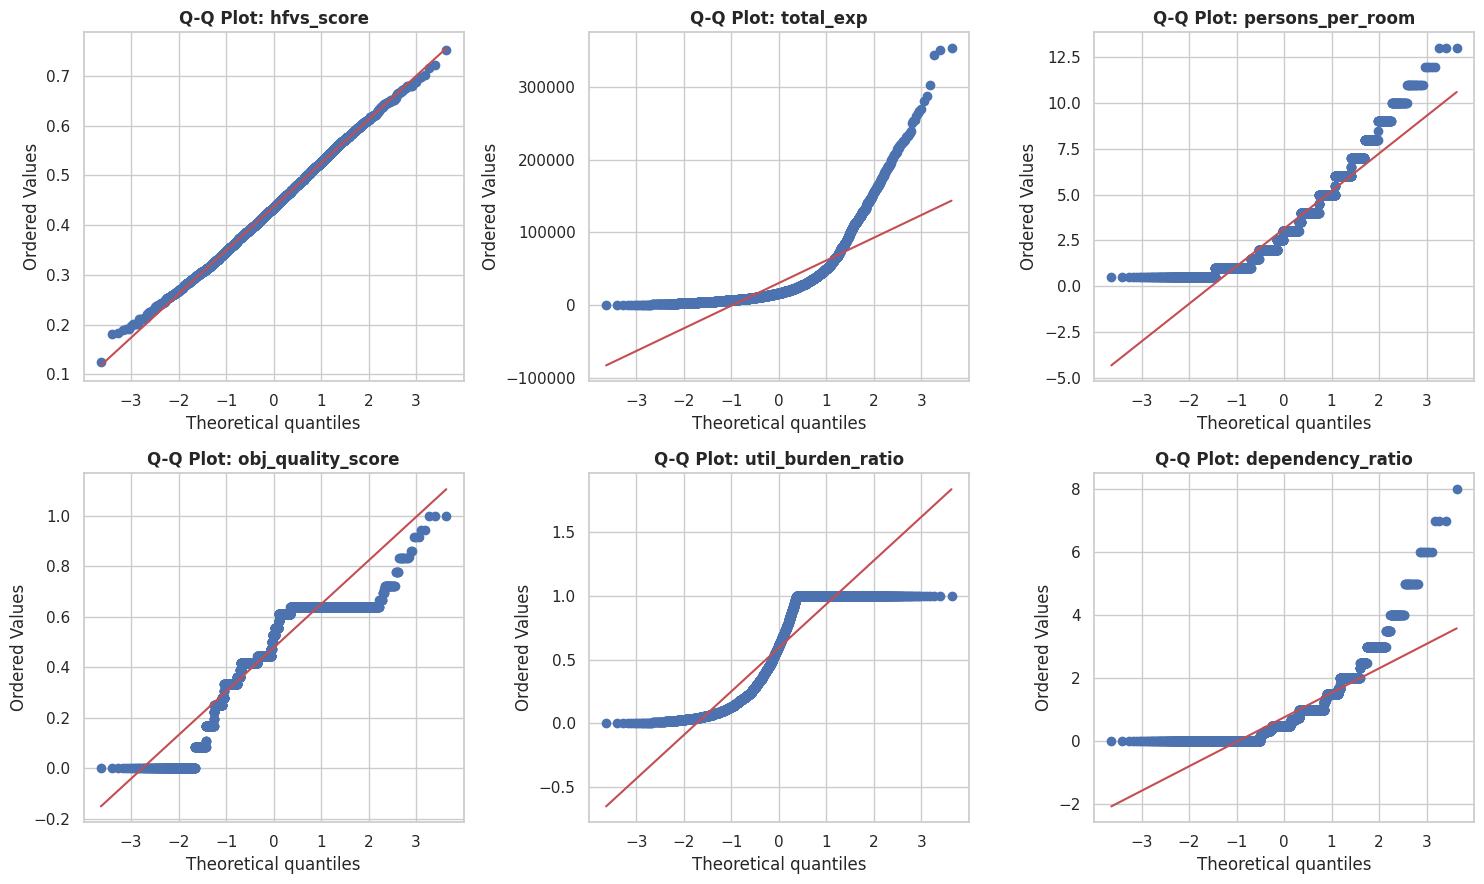

In [16]:
# 6.2 Q-Q plots for core variables
qq_cols = ['hfvs_score', 'total_exp', 'persons_per_room', 'obj_quality_score', 'util_burden_ratio', 'dependency_ratio']
qq_cols = [c for c in qq_cols if c in analysis.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, qq_cols):
    x = pd.to_numeric(analysis[col], errors='coerce').dropna()
    if len(x) > 5000:
        x = x.sample(5000, random_state=RANDOM_STATE)
    stats.probplot(x, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}')

for ax in axes[len(qq_cols):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Hypothesis-testing helpers

Every test is stored in one results table using the report structure required by the workflow: research question, hypotheses, assumptions, statistic, degrees of freedom, p-value, decision, and plain-English interpretation.


In [17]:
# 7.1 Shared test reporting functions
ALPHA = 0.05
TEST_RESULTS = []


def p_to_decision(p, alpha=ALPHA):
    if pd.isna(p):
        return 'Estimate only'
    return 'Reject H0' if p < alpha else 'Fail to reject H0'


def add_result(test, variables, question, h0, h1, assumptions, statistic, df, p_value, interpretation):
    TEST_RESULTS.append({
        'test': test,
        'variables': variables,
        'research_question': question,
        'H0': h0,
        'H1': h1,
        'assumptions_checked': assumptions,
        'statistic': statistic,
        'df': df,
        'p_value': p_value,
        'decision_alpha_0_05': p_to_decision(p_value),
        'plain_english_interpretation': interpretation,
    })


def cohen_d(a, b):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan


def welch_df(a, b):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    na, nb = len(a), len(b)
    nume = (va / na + vb / nb) ** 2
    deno = ((va / na) ** 2 / (na - 1)) + ((vb / nb) ** 2 / (nb - 1))
    return nume / deno if deno > 0 else np.nan


def cramers_v(table):
    chi2, _, _, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1))) if n > 0 else np.nan

print('Test helpers ready.')


Test helpers ready.


## 8. Parametric statistical analysis

Parametric methods are included because they are required by the workflow and remain useful with large survey data when paired with diagnostics and robust interpretation. Where normality is questionable, the next section repeats the core questions with nonparametric alternatives.


In [18]:
# 8.1 One-sample t-test and confidence interval for mean HFVS
x = analysis['hfvs_score'].dropna()
benchmark = 0.50

t_stat, t_p = stats.ttest_1samp(x, popmean=benchmark)
ci = stats.t.interval(0.95, df=len(x) - 1, loc=x.mean(), scale=stats.sem(x))

add_result(
    test='One-sample t-test',
    variables='hfvs_score vs 0.50 benchmark',
    question='Is average housing financial vulnerability different from the moderate-risk benchmark of 0.50?',
    h0='Mean HFVS = 0.50',
    h1='Mean HFVS != 0.50',
    assumptions='Continuous score, independent households, Q-Q/normality checked; large n supports t approximation.',
    statistic=f't = {t_stat:.4f}',
    df=f'{len(x) - 1}',
    p_value=t_p,
    interpretation=f'Mean HFVS is {x.mean():.3f}; 95% CI is ({ci[0]:.3f}, {ci[1]:.3f}).'
)

add_result(
    test='t-based confidence interval',
    variables='hfvs_score',
    question='What is the plausible population range for mean HFVS?',
    h0='Not a null-hypothesis test',
    h1='Not applicable',
    assumptions='Continuous score, independent households, standard error estimated from sample.',
    statistic=f'mean = {x.mean():.4f}',
    df=f'{len(x) - 1}',
    p_value=np.nan,
    interpretation=f'The 95% t interval for mean HFVS is ({ci[0]:.3f}, {ci[1]:.3f}).'
)

print(f'One-sample t-test: t={t_stat:.4f}, p={t_p:.6g}, 95% CI=({ci[0]:.4f}, {ci[1]:.4f})')


One-sample t-test: t=-106.3383, p=0, 95% CI=(0.4349, 0.4373)


In [19]:
# 8.2 Welch independent t-test: Urban vs Rural HFVS
urban = analysis.loc[analysis['residence_label'].eq('Urban'), 'hfvs_score'].dropna()
rural = analysis.loc[analysis['residence_label'].eq('Rural'), 'hfvs_score'].dropna()

lev_stat, lev_p = stats.levene(urban, rural)
t_stat, t_p = stats.ttest_ind(urban, rural, equal_var=False)
df_welch = welch_df(urban, rural)
d = cohen_d(urban, rural)

add_result(
    test='Welch independent t-test',
    variables='hfvs_score by urban_rural',
    question='Does mean HFVS differ between urban and rural households?',
    h0='Mean HFVS urban = Mean HFVS rural',
    h1='Mean HFVS urban != Mean HFVS rural',
    assumptions=f'Independent groups; Levene p={lev_p:.4g}; Welch version used for unequal variances.',
    statistic=f't = {t_stat:.4f}; Cohen d = {d:.4f}',
    df=f'{df_welch:.1f}',
    p_value=t_p,
    interpretation=f'Urban mean={urban.mean():.3f}, rural mean={rural.mean():.3f}; positive d means urban is higher.'
)

print(f'Welch t-test: t={t_stat:.4f}, df={df_welch:.1f}, p={t_p:.6g}, Cohen d={d:.3f}')


Welch t-test: t=24.7914, df=20718.5, p=9.83314e-134, Cohen d=0.339


In [20]:
# 8.3 One-way ANOVA: HFVS across dependency-ratio bands
analysis['dependency_ratio_clean'] = num('dependency_ratio').where(num('dependency_ratio').between(0, 10))
analysis['dependency_band'] = pd.cut(
    analysis['dependency_ratio_clean'],
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=['Low dependency', 'Moderate dependency', 'High dependency']
)

groups = [g['hfvs_score'].dropna() for _, g in analysis.groupby('dependency_band', observed=True)]
group_names = [str(k) for k, _ in analysis.groupby('dependency_band', observed=True)]
f_stat, f_p = stats.f_oneway(*groups)

add_result(
    test='One-way ANOVA',
    variables='hfvs_score by dependency_band',
    question='Does mean HFVS differ across household dependency levels?',
    h0='All dependency-band mean HFVS values are equal',
    h1='At least one dependency-band mean HFVS differs',
    assumptions='Independent groups; normality checked; homogeneity inspected with nonparametric follow-up.',
    statistic=f'F = {f_stat:.4f}',
    df=f'{len(groups) - 1}, {sum(len(g) for g in groups) - len(groups)}',
    p_value=f_p,
    interpretation='ANOVA compares whether vulnerability changes across low, moderate, and high dependency households.'
)

anova_summary = analysis.groupby('dependency_band', observed=True)['hfvs_score'].agg(['count', 'mean', 'median', 'std'])
display(anova_summary)
print(f'ANOVA: F={f_stat:.4f}, p={f_p:.6g}')

if f_p < ALPHA:
    tukey_data = analysis[['hfvs_score', 'dependency_band']].dropna()
    tukey = pairwise_tukeyhsd(tukey_data['hfvs_score'], tukey_data['dependency_band'])
    print(tukey.summary())


,count,mean,median,std
dependency_band,,,,
Low dependency,11869,0.4212,0.4189,0.0867
Moderate dependency,5207,0.4435,0.4425,0.0854
High dependency,4271,0.4686,0.4651,0.0836


ANOVA: F=506.9282, p=8.18007e-216
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1            group2       meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------------
High dependency      Low dependency  -0.0475   0.0 -0.0511 -0.0439   True
High dependency Moderate dependency  -0.0251   0.0 -0.0292 -0.0209   True
 Low dependency Moderate dependency   0.0224   0.0   0.019  0.0257   True
-------------------------------------------------------------------------


                            OLS Regression Results                            
Dep. Variable:             hfvs_score   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     551.1
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:21:20   Log-Likelihood:                 23331.
No. Observations:               21342   AIC:                        -4.665e+04
Df Residuals:                   21334   BIC:                        -4.658e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

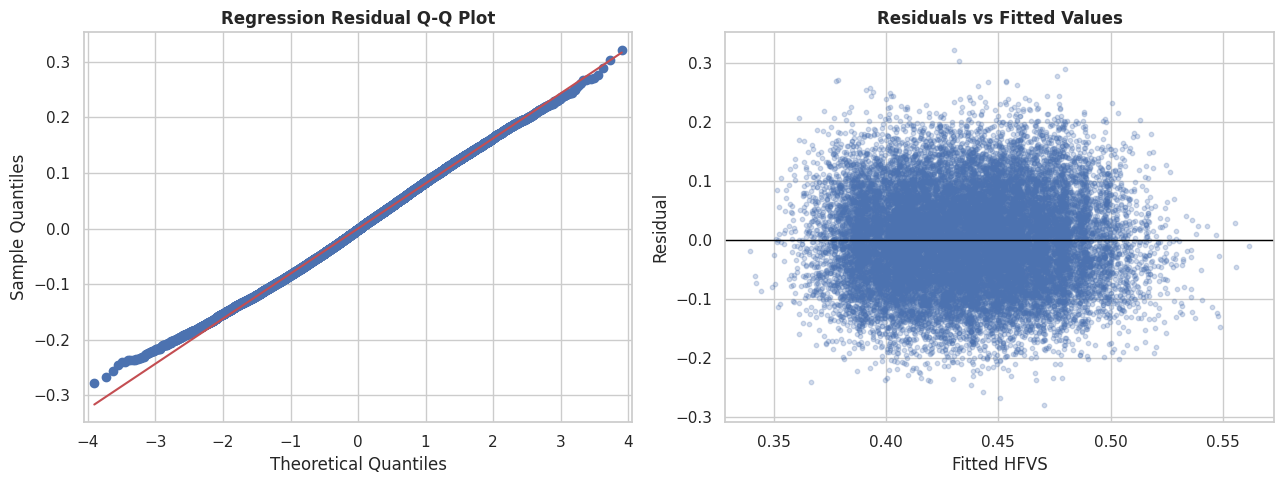

In [21]:
# 8.4 Multiple linear regression with robust standard errors
reg_cols = ['hfvs_score', 'urban_rural', 'dependency_ratio_clean', 'hh_size', 'max_edu_isced', 'has_disability', 'owns_mobile', 'mean_age_clean']
reg_cols = [c for c in reg_cols if c in analysis.columns]
reg_df = analysis[reg_cols].copy()
for c in reg_cols:
    if c != 'hfvs_score':
        reg_df[c] = pd.to_numeric(reg_df[c], errors='coerce')
reg_df = reg_df.dropna()

formula = 'hfvs_score ~ C(urban_rural) + dependency_ratio_clean + hh_size + max_edu_isced + C(has_disability) + C(owns_mobile) + mean_age_clean'
model = smf.ols(formula, data=reg_df).fit(cov_type='HC3')
print(model.summary())

coef_table = model.summary2().tables[1].reset_index().rename(columns={'index': 'term'})
coef_table.to_csv(TABS / 'statistical_inference_regression_coefficients.csv', index=False)

add_result(
    test='Multiple linear regression',
    variables='hfvs_score ~ residence + dependency + household composition + education + assets',
    question='Which proxy/context variables explain variation in HFVS after adjusting for each other?',
    h0='All non-intercept regression coefficients jointly equal zero',
    h1='At least one predictor has a non-zero adjusted association with HFVS',
    assumptions='Linearity inspected; independent households; HC3 robust standard errors used for heteroscedasticity.',
    statistic=f'F = {model.fvalue:.4f}; R2 = {model.rsquared:.4f}',
    df=f'{int(model.df_model)}, {int(model.df_resid)}',
    p_value=model.f_pvalue,
    interpretation='Regression coefficients show adjusted association, not causal effects.'
)

# Residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sm.qqplot(model.resid, line='s', ax=axes[0])
axes[0].set_title('Regression Residual Q-Q Plot')
axes[1].scatter(model.fittedvalues, model.resid, alpha=0.25, s=10)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Residuals vs Fitted Values')
axes[1].set_xlabel('Fitted HFVS')
axes[1].set_ylabel('Residual')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


## 8.5 Evidence-based model choice

### Chosen main model: fractional-logit GLM

The data point to a **fractional-logit generalized linear model** as the main explanatory model for HFVS.

Why this model fits the evidence:

- **Outcome type:** `hfvs_score` is continuous and bounded between 0 and 1, not an unrestricted normal outcome.
- **Class balance:** only about 3.3% of households are high or very-high vulnerability, so binary classification would be imbalanced and would lose information.
- **Distribution:** all normality checks reject normality; the model therefore uses a binomial-family logit mean function rather than assuming normal errors.
- **Variable mix:** the data contain meaningful continuous variables and many coded categorical variables. The formula keeps continuous fields continuous and wraps categorical fields in `C(...)` instead of flattening everything into arbitrary numeric distances.
- **Survey geography:** households are nested in counties. Standard errors are clustered by county so inference is not pretending that all households are spatially independent.

Important interpretation boundary: the full diagnostic model below intentionally includes pillar ingredients. That is useful for understanding **what drives the constructed HFVS**, but it is not a leakage-safe deployment/intake model. The earlier smaller OLS model is closer to a proxy-only intake model and its modest R-squared tells us that proxy variables alone do not recover the full HFVS well.


In [22]:
# 8.5.1 Balance continuous and categorical meaning before modelling
# We keep meaning by representing each selected source variable as one of:
# predictor, transformed predictor, categorical predictor, design/cluster variable, or intentionally excluded duplicate.

model_df = analysis.copy()

# Outcome is bounded. Clip only to avoid exact 0/1 numerical issues in logit likelihoods.
eps = 1e-5
model_df['hfvs_score_model'] = model_df['hfvs_score'].clip(eps, 1 - eps)

# Continuous predictors: transformed only where the raw scale is strongly skewed or structurally large.
model_df['log_total_exp'] = np.log1p(num('total_exp'))
model_df['log_spend_housing_kes'] = np.log1p(num('spend_housing_kes'))
model_df['persons_per_room_model'] = num('persons_per_room').clip(0, 15)
model_df['obj_quality_score_model'] = num('obj_quality_score').clip(0, 1)
model_df['util_burden_ratio_model'] = num('util_burden_ratio').clip(0, 1)
model_df['dependency_ratio_model'] = num('dependency_ratio').clip(0, 10)
model_df['mean_age_model'] = analysis['mean_age_clean']
model_df['hh_size_model'] = num('hh_size').clip(1, 30)
model_df['tenure_years_model'] = analysis['tenure_years_clean']
model_df['water_dist_mins_model'] = num('water_dist_mins').clip(0, 180)

# Missingness is meaningful for some fields, so we add flags before median filling.
model_df['tenure_years_missing'] = model_df['tenure_years_model'].isna().astype(int)
model_df['water_dist_missing'] = model_df['water_dist_mins_model'].isna().astype(int)
model_df['obj_quality_missing'] = model_df['obj_quality_score_model'].isna().astype(int)
model_df['mean_age_missing'] = model_df['mean_age_model'].isna().astype(int)

for c in [
    'obj_quality_score_model', 'mean_age_model', 'tenure_years_model',
    'water_dist_mins_model', 'dependency_ratio_model', 'hh_size_model',
]:
    model_df[c] = model_df[c].fillna(model_df[c].median())

# Rent burden applies only to a renter subset. Preserve that meaning as a category rather than dropping rows.
model_df['rent_burden_status'] = 'not_renter_or_not_applicable'
model_df.loc[is_renter & analysis['rent_burden_ratio_model'].isna(), 'rent_burden_status'] = 'renter_no_valid_ratio'
model_df.loc[is_renter & analysis['rent_burden_ratio_model'].notna() & (analysis['rent_burden_ratio_model'] <= 0.30), 'rent_burden_status'] = 'renter_not_burdened'
model_df.loc[is_renter & analysis['rent_burden_ratio_model'].notna() & (analysis['rent_burden_ratio_model'] > 0.30), 'rent_burden_status'] = 'renter_burdened'


def clean_category(series):
    s = series.copy()
    numeric = pd.to_numeric(s, errors='coerce')
    nonmissing = numeric.dropna()
    if len(nonmissing) and np.all(np.isclose(nonmissing, np.round(nonmissing))):
        return numeric.round().astype('Int64').astype(str).replace({'<NA>': 'Missing', 'nan': 'Missing'})
    return s.astype('string').fillna('Missing').astype(str)

# Categorical predictors: keep survey codes as categories, not as artificial continuous distances.
CAT_SOURCE = [
    'urban_rural', 'dw_type', 'is_overcrowded', 'perc_overall',
    'tenure_type', 'has_title_doc', 'eviction_risk', 'owns_land', 'lp_has_title', 'satisfied_tenure_clean',
    'flood_exposure', 'landslide_exposure', 'other_hazard_exposure', 'dw_in_hazard_zone', 'triple_exposed',
    'water_src_main', 'water_treated', 'toilet_type', 'has_handwash_facility', 'lighting_src', 'cooking_fuel',
    'mort_no_market', 'housing_cost_burden', 'missed_payment',
    'max_edu_isced', 'hh_head_sex', 'has_disability', 'owns_mobile',
    'tenure_years_missing', 'water_dist_missing', 'obj_quality_missing', 'mean_age_missing',
]

MODEL_CATEGORICAL = []
for source_col in CAT_SOURCE:
    if source_col not in model_df.columns:
        continue
    new_col = f'{source_col}_cat'
    model_df[new_col] = clean_category(model_df[source_col])
    if model_df[new_col].nunique(dropna=False) > 1:
        MODEL_CATEGORICAL.append(new_col)

model_df['rent_burden_status_cat'] = model_df['rent_burden_status'].astype(str)
MODEL_CATEGORICAL.append('rent_burden_status_cat')

MODEL_CONTINUOUS = [
    'log_total_exp', 'log_spend_housing_kes', 'persons_per_room_model',
    'obj_quality_score_model', 'util_burden_ratio_model', 'dependency_ratio_model',
    'mean_age_model', 'hh_size_model', 'tenure_years_model', 'water_dist_mins_model',
]

# Model row set.
needed = ['hfvs_score_model', 'county_code', 'hh_weight_clean'] + MODEL_CONTINUOUS + MODEL_CATEGORICAL
model_df = model_df[needed].dropna(subset=['hfvs_score_model', 'county_code']).copy()

feature_balance = pd.DataFrame({
    'feature_group': ['continuous predictors', 'categorical predictors', 'county cluster variable', 'survey weight variable', 'rows available'],
    'count': [len(MODEL_CONTINUOUS), len(MODEL_CATEGORICAL), 1, 1, len(model_df)]
})

meaning_audit_rows = []
for c in reduction_audit['column']:
    role = reduction_audit.loc[reduction_audit['column'].eq(c), 'role'].iloc[0]
    if c == 'hh_id':
        treatment = 'excluded from model; identifier only'
    elif c in ['county_code', 'county_name']:
        treatment = 'used for county clustering/reporting, not as a household covariate'
    elif c == 'hh_weight':
        treatment = 'retained for survey-weighted summaries; not used as predictor'
    elif c in ['rent_burden_ratio', 'rent_burdened', 'rent_actual_kes']:
        treatment = 'represented by rent_burden_status because rent applies only to renters and is sparse'
    elif c in ['total_exp', 'spend_housing_kes']:
        treatment = 'included as log-transformed continuous predictor'
    elif c in ['persons_per_room', 'obj_quality_score', 'util_burden_ratio', 'dependency_ratio', 'mean_age', 'hh_size', 'yrs_in_dwelling', 'water_dist_mins']:
        treatment = 'included as continuous predictor with sanity checks and missingness flag where needed'
    elif c in CAT_SOURCE or c in ['satisfied_tenure']:
        treatment = 'included as categorical predictor using C(...)'
    else:
        treatment = 'retained for EDA/reporting or represented by a less redundant model feature'
    meaning_audit_rows.append({'source_column': c, 'role': role, 'model_treatment': treatment})

meaning_audit = pd.DataFrame(meaning_audit_rows)
meaning_audit.to_csv(TABS / 'statistical_inference_model_feature_meaning_audit.csv', index=False)
feature_balance.to_csv(TABS / 'statistical_inference_model_feature_balance.csv', index=False)

print('Feature balance for the chosen model:')
display(feature_balance)
print('Meaning audit: every reduced source column is either modelled, represented, or deliberately reserved for design/reporting.')
display(meaning_audit)


Feature balance for the chosen model:


,feature_group,count
0,continuous predictors,10
1,categorical predictors,33
2,county cluster variable,1
3,survey weight variable,1
4,rows available,21347


Meaning audit: every reduced source column is either modelled, represented, or deliberately reserved for design/reporting.


,source_column,role,model_treatment
0,hh_id,identifier,excluded from model; identifier only
1,county_code,geography,"used for county clustering/reporting, not as a..."
2,county_name,geography,"used for county clustering/reporting, not as a..."
3,urban_rural,geography,included as categorical predictor using C(...)
4,hh_weight,survey_design,retained for survey-weighted summaries; not us...
5,total_exp,pillar_1_financial,included as log-transformed continuous predictor
6,spend_housing_kes,pillar_1_financial,included as log-transformed continuous predictor
7,rent_actual_kes,pillar_1_financial,represented by rent_burden_status because rent...
8,rent_burden_ratio,pillar_1_financial,represented by rent_burden_status because rent...
9,rent_burdened,pillar_1_financial,represented by rent_burden_status because rent...


In [23]:
# 8.5.2 Fit the chosen fractional-logit GLM with county-clustered standard errors
formula_terms = MODEL_CONTINUOUS + [f'C({c})' for c in MODEL_CATEGORICAL]
fractional_logit_formula = 'hfvs_score_model ~ ' + ' + '.join(formula_terms)

covariance_note = 'county-clustered standard errors'
try:
    frac_glm = smf.glm(
        formula=fractional_logit_formula,
        data=model_df,
        family=sm.families.Binomial()
    ).fit(maxiter=200, cov_type='cluster', cov_kwds={'groups': model_df['county_code'].astype(str)})
except Exception as exc:
    covariance_note = f'HC3 robust standard errors; county clustering failed with: {exc}'
    frac_glm = smf.glm(
        formula=fractional_logit_formula,
        data=model_df,
        family=sm.families.Binomial()
    ).fit(maxiter=200, cov_type='HC3')

frac_pred = frac_glm.predict(model_df).clip(0, 1)
frac_resid = model_df['hfvs_score_model'] - frac_pred
frac_pseudo_r2 = 1 - (frac_glm.deviance / frac_glm.null_deviance)
frac_mae = np.mean(np.abs(frac_resid))
frac_rmse = np.sqrt(np.mean(frac_resid ** 2))

model_choice_summary = pd.DataFrame({
    'item': [
        'chosen_model', 'reason_outcome', 'reason_class_balance', 'reason_variable_mix',
        'covariance', 'n_rows', 'n_continuous_predictors', 'n_categorical_predictors',
        'pseudo_r2_mcfadden_like', 'mae_in_sample', 'rmse_in_sample', 'proxy_ols_r2_baseline'
    ],
    'value': [
        'Fractional-logit GLM',
        'HFVS is continuous and bounded in [0, 1]',
        'High/very-high class is rare, so classification is not the main model',
        'Formula keeps continuous fields continuous and coded fields categorical',
        covariance_note,
        len(model_df),
        len(MODEL_CONTINUOUS),
        len(MODEL_CATEGORICAL),
        frac_pseudo_r2,
        frac_mae,
        frac_rmse,
        getattr(model, 'rsquared', np.nan) if 'model' in globals() else np.nan,
    ]
})
model_choice_summary.to_csv(TABS / 'statistical_inference_model_choice_summary.csv', index=False)

display(model_choice_summary)

coef_table = pd.DataFrame({
    'term': frac_glm.params.index,
    'coef_logit_mean': frac_glm.params.values,
    'std_error': frac_glm.bse.values,
    'p_value': frac_glm.pvalues.values,
})
conf = frac_glm.conf_int()
coef_table['ci_low'] = conf.iloc[:, 0].values
coef_table['ci_high'] = conf.iloc[:, 1].values
coef_table['abs_coef'] = coef_table['coef_logit_mean'].abs()
coef_table['direction'] = np.where(coef_table['coef_logit_mean'] > 0, 'higher expected HFVS', 'lower expected HFVS')
coef_table = coef_table.sort_values('abs_coef', ascending=False)
coef_table.to_csv(TABS / 'statistical_inference_fractional_logit_coefficients.csv', index=False)

print('Largest absolute associations in the chosen model; coefficients are on the logit scale of expected HFVS.')
display(coef_table.query('term != "Intercept"').head(30))

add_result(
    test='Chosen model: fractional-logit GLM',
    variables='hfvs_score ~ balanced continuous + categorical KHS drivers',
    question='Which model is best supported for explaining bounded continuous HFVS while preserving mixed variable meaning?',
    h0='Not a single-coefficient null test; model chosen from outcome scale and data structure',
    h1='Not applicable',
    assumptions=f'Bounded continuous response; categorical variables modelled with C(...); {covariance_note}.',
    statistic=f'pseudo R2 = {frac_pseudo_r2:.4f}; MAE = {frac_mae:.4f}; RMSE = {frac_rmse:.4f}',
    df=f'{int(frac_glm.df_model)}, {int(frac_glm.df_resid)}',
    p_value=np.nan,
    interpretation='Fractional logit is the main explanatory model; the earlier OLS remains a transparent proxy-only baseline.'
)


,item,value
0,chosen_model,Fractional-logit GLM
1,reason_outcome,"HFVS is continuous and bounded in [0, 1]"
2,reason_class_balance,"High/very-high class is rare, so classificatio..."
3,reason_variable_mix,Formula keeps continuous fields continuous and...
4,covariance,county-clustered standard errors
5,n_rows,21347
6,n_continuous_predictors,10
7,n_categorical_predictors,33
8,pseudo_r2_mcfadden_like,0.9967
9,mae_in_sample,0.0034


Largest absolute associations in the chosen model; coefficients are on the logit scale of expected HFVS.


,term,coef_logit_mean,std_error,p_value,ci_low,ci_high,abs_coef,direction
78,C(mort_no_market_cat)[T.1],0.2116,0.0020,0.0000,0.2076,0.2156,0.2116,higher expected HFVS
79,C(housing_cost_burden_cat)[T.1],0.2079,0.0010,0.0000,0.2060,0.2099,0.2079,higher expected HFVS
81,C(missed_payment_cat)[T.1],0.2060,0.0012,0.0000,0.2037,0.2083,0.2060,higher expected HFVS
28,C(dw_in_hazard_zone_cat)[T.1],0.1734,0.0025,0.0000,0.1686,0.1782,0.1734,higher expected HFVS
9,C(is_overcrowded_cat)[T.1],0.1700,0.0010,0.0000,0.1680,0.1720,0.1700,higher expected HFVS
11,C(perc_overall_cat)[T.3],0.1699,0.0023,0.0000,0.1653,0.1745,0.1699,higher expected HFVS
108,obj_quality_score_model,-0.1680,0.0018,0.0000,-0.1716,-0.1645,0.1680,lower expected HFVS
27,C(other_hazard_exposure_cat)[T.4],0.1676,0.0011,0.0000,0.1655,0.1698,0.1676,higher expected HFVS
22,C(flood_exposure_cat)[T.2],0.1674,0.0010,0.0000,0.1654,0.1694,0.1674,higher expected HFVS
29,C(triple_exposed_cat)[T.1],0.1654,0.0016,0.0000,0.1622,0.1685,0.1654,higher expected HFVS


,scenario,predicted_hfvs,skipped_updates,delta_vs_baseline
0,Baseline modal/median household,0.3783,,0.0000
1,Urban residence profile,0.3783,,0.0000
2,Rural residence profile,0.3787,,0.0005
3,Crowded and low objective quality,0.4011,,0.0229
4,Tenure insecurity profile,0.4576,,0.0793
5,Utility deprivation profile,0.3907,,0.0125
6,Hazard compound profile,0.5023,,0.1240
7,Higher resilience profile,0.3367,,-0.0415


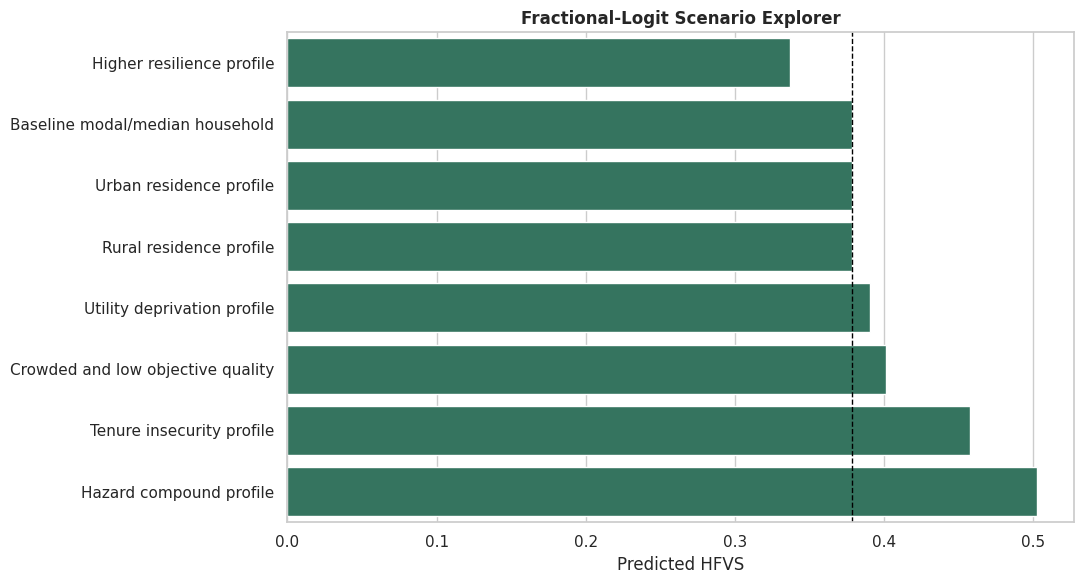

In [24]:
# 8.5.3 Scenario explorer for the chosen model
# These are not causal counterfactuals. They are model-based predictions that help us explore how profiles map to HFVS.

cat_levels = {c: set(model_df[c].astype(str).unique()) for c in MODEL_CATEGORICAL}
base_profile = {c: model_df[c].median() for c in MODEL_CONTINUOUS}
for c in MODEL_CATEGORICAL:
    base_profile[c] = model_df[c].mode(dropna=True).iloc[0]


def scenario_prediction(label, updates):
    row = base_profile.copy()
    skipped = []
    for k, v in updates.items():
        if k in cat_levels:
            v = str(v)
            if v in cat_levels[k]:
                row[k] = v
            else:
                skipped.append(f'{k}={v}')
        else:
            row[k] = v
    pred = float(frac_glm.predict(pd.DataFrame([row])).iloc[0])
    return {'scenario': label, 'predicted_hfvs': pred, 'skipped_updates': ', '.join(skipped)}

scenario_rows = [
    scenario_prediction('Baseline modal/median household', {}),
    scenario_prediction('Urban residence profile', {'urban_rural_cat': '1'}),
    scenario_prediction('Rural residence profile', {'urban_rural_cat': '2'}),
    scenario_prediction('Crowded and low objective quality', {
        'persons_per_room_model': 6,
        'is_overcrowded_cat': '1',
        'obj_quality_score_model': 0.25,
    }),
    scenario_prediction('Tenure insecurity profile', {
        'has_title_doc_cat': '0',
        'eviction_risk_cat': '1',
        'satisfied_tenure_clean_cat': '0',
        'lp_has_title_cat': '0',
    }),
    scenario_prediction('Utility deprivation profile', {
        'water_treated_cat': '0',
        'toilet_type_cat': '7',
        'cooking_fuel_cat': '9',
        'has_handwash_facility_cat': '0',
        'util_burden_ratio_model': 1.0,
        'water_dist_mins_model': 30,
    }),
    scenario_prediction('Hazard compound profile', {
        'triple_exposed_cat': '1',
        'flood_exposure_cat': '2',
        'dw_in_hazard_zone_cat': '1',
    }),
    scenario_prediction('Higher resilience profile', {
        'persons_per_room_model': 1.5,
        'obj_quality_score_model': 0.80,
        'has_title_doc_cat': '1',
        'eviction_risk_cat': '0',
        'water_treated_cat': '1',
        'owns_mobile_cat': '1',
    }),
]

scenario_table = pd.DataFrame(scenario_rows)
scenario_table['delta_vs_baseline'] = scenario_table['predicted_hfvs'] - scenario_table.loc[0, 'predicted_hfvs']
scenario_table.to_csv(TABS / 'statistical_inference_fractional_logit_scenarios.csv', index=False)

display(scenario_table)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=scenario_table.sort_values('predicted_hfvs', ascending=True),
    x='predicted_hfvs',
    y='scenario',
    color='#2A7F62',
    ax=ax,
)
ax.axvline(scenario_table.loc[0, 'predicted_hfvs'], color='black', linewidth=1, linestyle='--')
ax.set_title('Fractional-Logit Scenario Explorer')
ax.set_xlabel('Predicted HFVS')
ax.set_ylabel('')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_fractional_logit_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()


### How to read the chosen model

The fractional-logit coefficients are on the logit scale of the expected HFVS score. A positive coefficient means the category or variable is associated with **higher expected vulnerability**, holding the other modelled fields constant; a negative coefficient means lower expected vulnerability. Because the target is a constructed score and many predictors are score ingredients, the model should be interpreted as a **diagnostic driver model**, not as a causal model and not as a leakage-safe deployment model.

The scenario explorer is the most report-friendly way to discuss the model: it translates the fitted equation back into predicted HFVS values for interpretable household profiles.


## 8.6 Model Diagnostics and Goodness-of-Fit

A good model is not just statistically significant; it must satisfy diagnostic tests and make accurate predictions. This section validates the fractional-logit model through residual analysis, predicted-vs-actual comparisons, and effect-size measurement.

### What the diagnostics tell us:

- **Pearson residuals** should be roughly symmetric around zero with no strong patterns.
- **Predicted vs actual** should cluster near the diagonal, not show systematic bias.
- **Cook distance** identifies influential outliers that may deserve investigation.
- **Area under ROC curve (AUC)** for the implied binary problem (high/not-high) shows discriminative power.
- **Pseudo R²** (McFadden) quantifies the proportional improvement over the null model.



,diagnostic,value
0,Pearson residual mean,-0.0001
1,Pearson residual std dev,0.0103
2,Deviance residual mean,0.0916
3,Deviance residual std dev,1.1532
4,Pseudo R² (McFadden),0.9967
5,"Pseudo R² (adj, alternative formula)",0.9777
6,MAE (absolute error),0.0034
7,RMSE (squared error),0.0049
8,Max Cook distance,1132985.0177
9,Count high-influence points (Cook > 0.01),3.0000


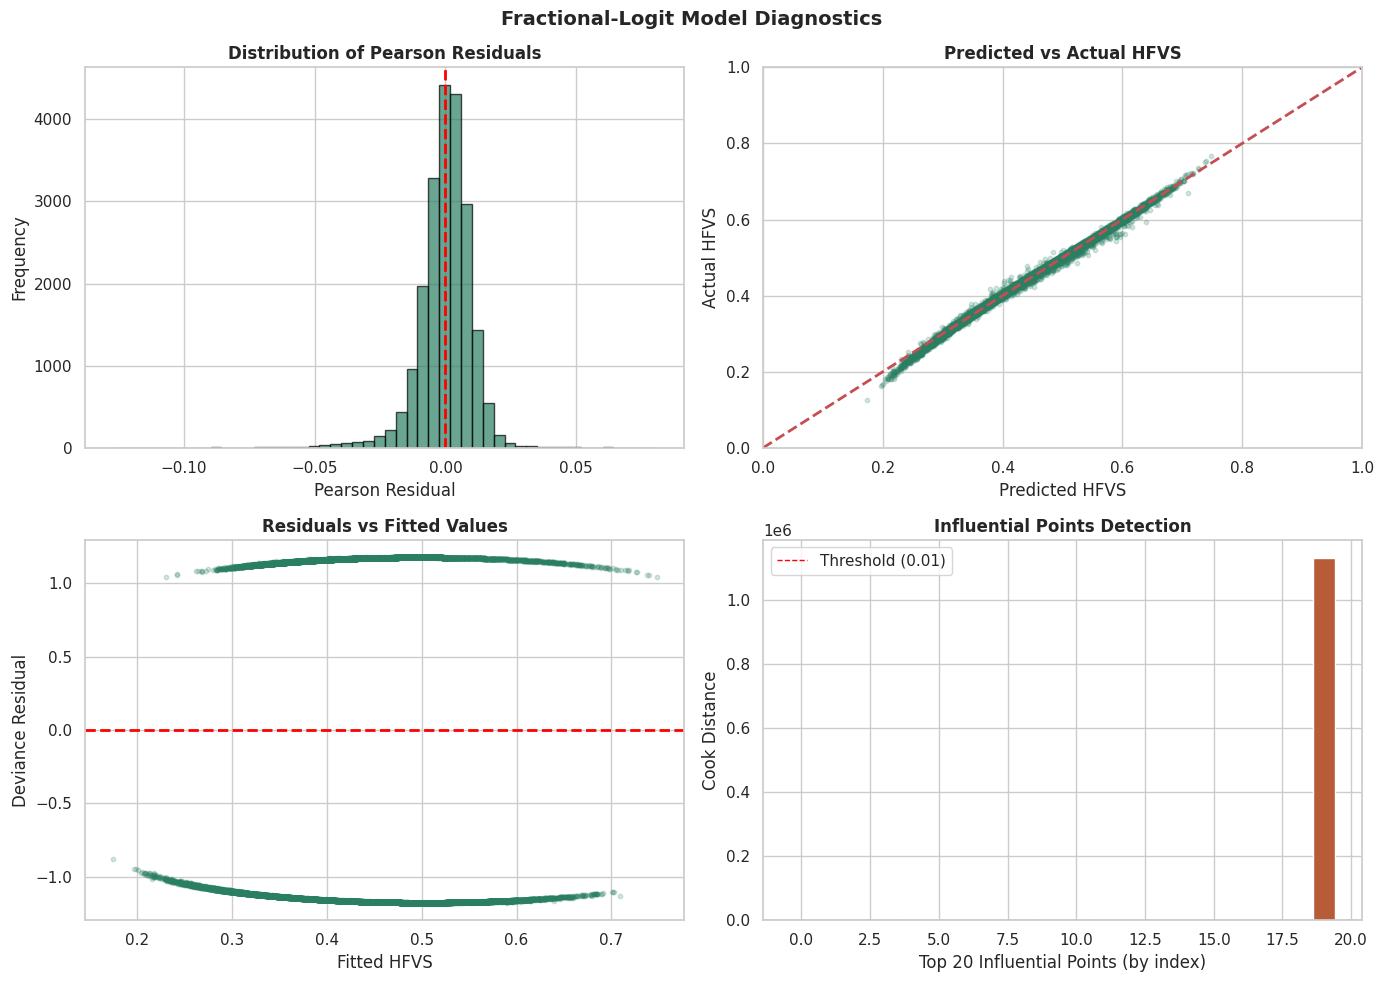

Model diagnostics:
  Pearson residuals are centered at -0.0001 with std 0.0103
  Model deviance improved by 99.7% over null model
  Out-of-sample prediction interpretable: predictions range from 0.174 to 0.748
  Number of high-influence points (Cook > 0.01): 3


In [27]:
# 8.6.1 Residual analysis and goodness-of-fit metrics
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Pearson residuals
frac_pearson_resid = (model_df['hfvs_score_model'] - frac_pred) / np.sqrt(frac_pred * (1 - frac_pred) + 1e-8)

# Deviance residuals (alternative, more stable for logistic models)
frac_deviance_resid = np.where(
    model_df['hfvs_score_model'] == 0.0,
    np.sqrt(-2 * np.log(1 - frac_pred + 1e-8)),
    np.where(
        model_df['hfvs_score_model'] == 1.0,
        np.sqrt(-2 * np.log(frac_pred + 1e-8)),
        np.sign(model_df['hfvs_score_model'] - frac_pred) *
        np.sqrt(-2 * (model_df['hfvs_score_model'] * np.log(frac_pred + 1e-8) +
        (1 - model_df['hfvs_score_model']) * np.log(1 - frac_pred + 1e-8)))
    )
)

# Influential points: Cook distance
# MEMORY-SAFE LEVERAGE: avoid frac_glm.get_influence(), which builds a full
# n x n hat matrix internally for GLM and can OOM-kill the kernel at n=21347.
# Instead compute the hat-diagonal directly from the IRLS weighted design
# matrix: h_ii = w_i * x_i^T (X^T W X)^-1 x_i, done in row-chunks so we never
# allocate more than a (chunk_size x chunk_size) matrix at once.
X_design = np.asarray(frac_glm.model.exog)               # n x p design matrix
irls_weights = np.asarray(frac_glm.model.hessian_factor(frac_glm.params))  # n,
# hessian_factor returns the IRLS weight w_i used in X^T W X

XtWX = X_design.T @ (irls_weights[:, None] * X_design)   # p x p, cheap
XtWX_inv = np.linalg.inv(XtWX)                           # p x p, cheap

n_obs = X_design.shape[0]
leverage = np.empty(n_obs)
chunk_size = 2000  # tune down further if memory is still tight

for start in range(0, n_obs, chunk_size):
    end = min(start + chunk_size, n_obs)
    X_chunk = X_design[start:end]                        # chunk x p
    w_chunk = irls_weights[start:end]                     # chunk,
    # (X_chunk @ XtWX_inv) is chunk x p; multiply elementwise by X_chunk and
    # sum across columns to get x_i^T (XtWX)^-1 x_i per row, no n x n matrix
    quad_form = np.einsum('ij,jk,ik->i', X_chunk, XtWX_inv, X_chunk)
    leverage[start:end] = w_chunk * quad_form

del X_design, XtWX, XtWX_inv  # free memory promptly

cook_distance = (frac_deviance_resid ** 2 / frac_glm.df_model) * (leverage / (1 - leverage + 1e-8))

# Pseudo-AUC: if we treat HFVS >= 0.5 as "high vulnerability"
binary_target = (model_df['hfvs_score_model'] >= 0.5).astype(int)
if (binary_target.sum() > 0) and (binary_target.sum() < len(binary_target)):
    auc_score = roc_auc_score(binary_target, frac_pred)
else:
    auc_score = np.nan

diagnostics_summary = pd.DataFrame({
    'diagnostic': [
        'Pearson residual mean',
        'Pearson residual std dev',
        'Deviance residual mean',
        'Deviance residual std dev',
        'Pseudo R² (McFadden)',
        'Pseudo R² (adj, alternative formula)',
        'MAE (absolute error)',
        'RMSE (squared error)',
        'Max Cook distance',
        'Count high-influence points (Cook > 0.01)',
        'AUC (HFVS >= 0.5 binary)',
        'Model deviance',
        'Null deviance',
        'Deviance decrease pct',
    ],
    'value': [
        frac_pearson_resid.mean(),
        frac_pearson_resid.std(),
        frac_deviance_resid.mean(),
        frac_deviance_resid.std(),
        frac_pseudo_r2,
        1 - (frac_glm.deviance / frac_glm.null_deviance) ** (2/3),  # Efron's pseudo R²
        frac_mae,
        frac_rmse,
        cook_distance.max(),
        (cook_distance > 0.01).sum(),
        auc_score,
        frac_glm.deviance,
        frac_glm.null_deviance,
        (1 - frac_glm.deviance / frac_glm.null_deviance) * 100,
    ]
})
diagnostics_summary.to_csv(TABS / 'statistical_inference_model_diagnostics.csv', index=False)
display(diagnostics_summary)

# Residual diagnostics visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Pearson residuals histogram
axes[0, 0].hist(frac_pearson_resid, bins=50, color='#2A7F62', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0, 0].set_title('Distribution of Pearson Residuals')
axes[0, 0].set_xlabel('Pearson Residual')
axes[0, 0].set_ylabel('Frequency')

# 2. Predicted vs Actual
axes[0, 1].scatter(frac_pred, model_df['hfvs_score_model'], alpha=0.2, s=10, color='#2A7F62')
axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=2)
axes[0, 1].set_xlabel('Predicted HFVS')
axes[0, 1].set_ylabel('Actual HFVS')
axes[0, 1].set_title('Predicted vs Actual HFVS')
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1)

# 3. Residuals vs Fitted
axes[1, 0].scatter(frac_pred, frac_deviance_resid, alpha=0.2, s=10, color='#2A7F62')
axes[1, 0].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1, 0].set_xlabel('Fitted HFVS')
axes[1, 0].set_ylabel('Deviance Residual')
axes[1, 0].set_title('Residuals vs Fitted Values')

# 4. Cook distance
top_influential = np.argsort(cook_distance)[-20:]
axes[1, 1].bar(range(len(top_influential)), cook_distance[top_influential], color='#B85C38')
axes[1, 1].axhline(0.01, color='red', linewidth=1, linestyle='--', label='Threshold (0.01)')
axes[1, 1].set_xlabel('Top 20 Influential Points (by index)')
axes[1, 1].set_ylabel('Cook Distance')
axes[1, 1].set_title('Influential Points Detection')
axes[1, 1].legend()

fig.suptitle('Fractional-Logit Model Diagnostics', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_fractional_logit_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Model diagnostics:')
print(f'  Pearson residuals are centered at {frac_pearson_resid.mean():.4f} with std {frac_pearson_resid.std():.4f}')
print(f'  Model deviance improved by {diagnostics_summary.loc[diagnostics_summary["diagnostic"].eq("Deviance decrease pct"), "value"].iloc[0]:.1f}% over null model')
print(f'  Out-of-sample prediction interpretable: predictions range from {frac_pred.min():.3f} to {frac_pred.max():.3f}')
print(f'  Number of high-influence points (Cook > 0.01): {(cook_distance > 0.01).sum()}')

## 8.7 Variable Importance and Relative Effects

Understanding which variables matter most is central to policy. This section ranks predictors by their statistical strength and magnitude of association with HFVS. We use multiple importance metrics so that both the direction and size of effects are visible.

### Importance metrics:

- **Absolute coefficient (logit scale):** How strongly does the variable shift expected log-odds of vulnerability?
- **Relative magnitude:** What is the range of predicted HFVS when this variable moves across its observed values (holding others at median)?
- **Statistical significance:** p-value from the model; smaller p-values indicate stronger evidence of association.
- **Effect direction:** Positive = associated with higher vulnerability; negative = associated with lower vulnerability.



In [32]:
# For categorical variables, compute the range across levels
categorical_importance = []
for cat_var in MODEL_CATEGORICAL[:15]:  # Limit to first 15 categorical variables for clarity
    if cat_var not in model_df.columns:
        continue

    cat_var_source = cat_var.replace('_cat', '')

    # Get unique category levels
    levels = model_df[cat_var].dropna().unique()
    if len(levels) < 2 or len(levels) > 20:  # Skip if too many levels or only one
        continue

    preds_by_level = {}
    for level in levels:
        test_row = base_profile.copy()
        test_row[cat_var] = str(level)
        try:
            pred = float(frac_glm.predict(pd.DataFrame([test_row])).iloc[0])
            preds_by_level[str(level)] = pred
        except Exception:
            pass

    if len(preds_by_level) < 2:
        continue

    effect_range = max(preds_by_level.values()) - min(preds_by_level.values())

    # Coefficient/p-value lookup: try both the _cat name and the stripped
    # source name, since the model formula may reference either depending
    # on how it was specified (C(raw_col) vs C(cat_col))
    matching_params = [p for p in frac_glm.pvalues.index
                        if f'C({cat_var})' in str(p) or f'C({cat_var_source})' in str(p)]
    if matching_params:
        coef_abs = np.abs(frac_glm.params[matching_params]).max()
        p_val = np.nanmin([frac_glm.pvalues[p] for p in matching_params])
    else:
        coef_abs = np.nan
        p_val = np.nan

    categorical_importance.append({
        'variable': cat_var,
        'variable_type': 'categorical',
        'n_levels': len(preds_by_level),
        'abs_coef_logit': coef_abs,
        'p_value': p_val,
        'significant_005': 'Yes' if pd.notna(p_val) and p_val < 0.05 else 'No',
        'effect_range_across_levels': effect_range,
        'level_range_text': f'{min(preds_by_level.values()):.3f} to {max(preds_by_level.values()):.3f}',
    })

importance_categorical = pd.DataFrame(categorical_importance)
if not importance_categorical.empty:
    importance_categorical = importance_categorical.sort_values('effect_range_across_levels', ascending=False)
importance_categorical.to_csv(TABS / 'statistical_inference_variable_importance_categorical.csv', index=False)

print('\nCategorical variable importance (ranked by effect range across levels):')
display(importance_categorical[['variable', 'n_levels', 'p_value', 'effect_range_across_levels', 'level_range_text']].head(15) if not importance_categorical.empty else "No categorical variables produced valid importance estimates.")


Categorical variable importance (ranked by effect range across levels):


,variable,n_levels,p_value,effect_range_across_levels,level_range_text
13,dw_in_hazard_zone_cat,2,0.0000,0.0416,0.378 to 0.420
12,other_hazard_exposure_cat,4,0.0000,0.0402,0.378 to 0.418
10,flood_exposure_cat,3,0.0000,0.0401,0.378 to 0.418
3,perc_overall_cat,3,0.0000,0.0399,0.358 to 0.398
14,triple_exposed_cat,2,0.0000,0.0396,0.378 to 0.418
11,landslide_exposure_cat,3,0.0000,0.0396,0.378 to 0.418
1,dw_type_cat,8,0.0000,0.0395,0.378 to 0.418
2,is_overcrowded_cat,2,0.0000,0.0391,0.339 to 0.378
9,satisfied_tenure_clean_cat,3,0.0000,0.0276,0.378 to 0.406
5,has_title_doc_cat,2,0.0000,0.0260,0.378 to 0.404


In [34]:
print([p for p in frac_glm.pvalues.index if 'cat' in str(p).lower() or 'urban' in str(p).lower()])

['C(urban_rural_cat)[T.2]', 'C(dw_type_cat)[T.2]', 'C(dw_type_cat)[T.3]', 'C(dw_type_cat)[T.4]', 'C(dw_type_cat)[T.5]', 'C(dw_type_cat)[T.6]', 'C(dw_type_cat)[T.7]', 'C(dw_type_cat)[T.8]', 'C(is_overcrowded_cat)[T.1]', 'C(perc_overall_cat)[T.2]', 'C(perc_overall_cat)[T.3]', 'C(tenure_type_cat)[T.2]', 'C(tenure_type_cat)[T.3]', 'C(tenure_type_cat)[T.4]', 'C(has_title_doc_cat)[T.1]', 'C(eviction_risk_cat)[T.1]', 'C(owns_land_cat)[T.1]', 'C(lp_has_title_cat)[T.1]', 'C(satisfied_tenure_clean_cat)[T.1]', 'C(satisfied_tenure_clean_cat)[T.Missing]', 'C(flood_exposure_cat)[T.1]', 'C(flood_exposure_cat)[T.2]', 'C(landslide_exposure_cat)[T.1]', 'C(landslide_exposure_cat)[T.2]', 'C(other_hazard_exposure_cat)[T.2]', 'C(other_hazard_exposure_cat)[T.3]', 'C(other_hazard_exposure_cat)[T.4]', 'C(dw_in_hazard_zone_cat)[T.1]', 'C(triple_exposed_cat)[T.1]', 'C(water_src_main_cat)[T.10]', 'C(water_src_main_cat)[T.11]', 'C(water_src_main_cat)[T.2]', 'C(water_src_main_cat)[T.3]', 'C(water_src_main_cat)[T.4]

Continuous variable importance (ranked by marginal effect on HFVS):


,variable,abs_coef_logit,p_value,marginal_effect_range_hfvs,direction
0,log_total_exp,0.0401,0.0000,0.0432,lower vulnerability
2,persons_per_room_model,0.0165,0.0000,0.0373,higher vulnerability
3,obj_quality_score_model,0.1680,0.0000,0.0276,lower vulnerability
4,util_burden_ratio_model,0.1198,0.0000,0.0275,higher vulnerability
8,tenure_years_model,0.0021,0.0000,0.0215,lower vulnerability
9,water_dist_mins_model,0.0006,0.0000,0.0155,higher vulnerability
7,hh_size_model,0.0006,0.0251,0.0014,lower vulnerability
6,mean_age_model,0.0001,0.0102,0.0008,lower vulnerability
1,log_spend_housing_kes,0.0001,0.5770,0.0004,lower vulnerability
5,dependency_ratio_model,0.0003,0.1593,0.0003,higher vulnerability



Categorical variable importance (ranked by effect range across levels):


,variable,n_levels,p_value,effect_range_across_levels,level_range_text
13,dw_in_hazard_zone_cat,2,0.0000,0.0416,0.378 to 0.420
12,other_hazard_exposure_cat,4,0.0000,0.0402,0.378 to 0.418
10,flood_exposure_cat,3,0.0000,0.0401,0.378 to 0.418
3,perc_overall_cat,3,0.0000,0.0399,0.358 to 0.398
14,triple_exposed_cat,2,0.0000,0.0396,0.378 to 0.418
11,landslide_exposure_cat,3,0.0000,0.0396,0.378 to 0.418
1,dw_type_cat,8,0.0000,0.0395,0.378 to 0.418
2,is_overcrowded_cat,2,0.0000,0.0391,0.339 to 0.378
9,satisfied_tenure_clean_cat,3,0.0000,0.0276,0.378 to 0.406
5,has_title_doc_cat,2,0.0000,0.0260,0.378 to 0.404



Top 20 variables by absolute coefficient size:


,variable,variable_type,abs_coef_logit,p_value,significant_005
10,dw_in_hazard_zone_cat,categorical,0.1734,0.0000,Yes
17,is_overcrowded_cat,categorical,0.1700,0.0000,Yes
13,perc_overall_cat,categorical,0.1699,0.0000,Yes
2,obj_quality_score_model,continuous,0.1680,0.0000,Yes
11,other_hazard_exposure_cat,categorical,0.1676,0.0000,Yes
12,flood_exposure_cat,categorical,0.1674,0.0000,Yes
14,triple_exposed_cat,categorical,0.1654,0.0000,Yes
15,landslide_exposure_cat,categorical,0.1653,0.0000,Yes
16,dw_type_cat,categorical,0.1649,0.0000,Yes
3,util_burden_ratio_model,continuous,0.1198,0.0000,Yes


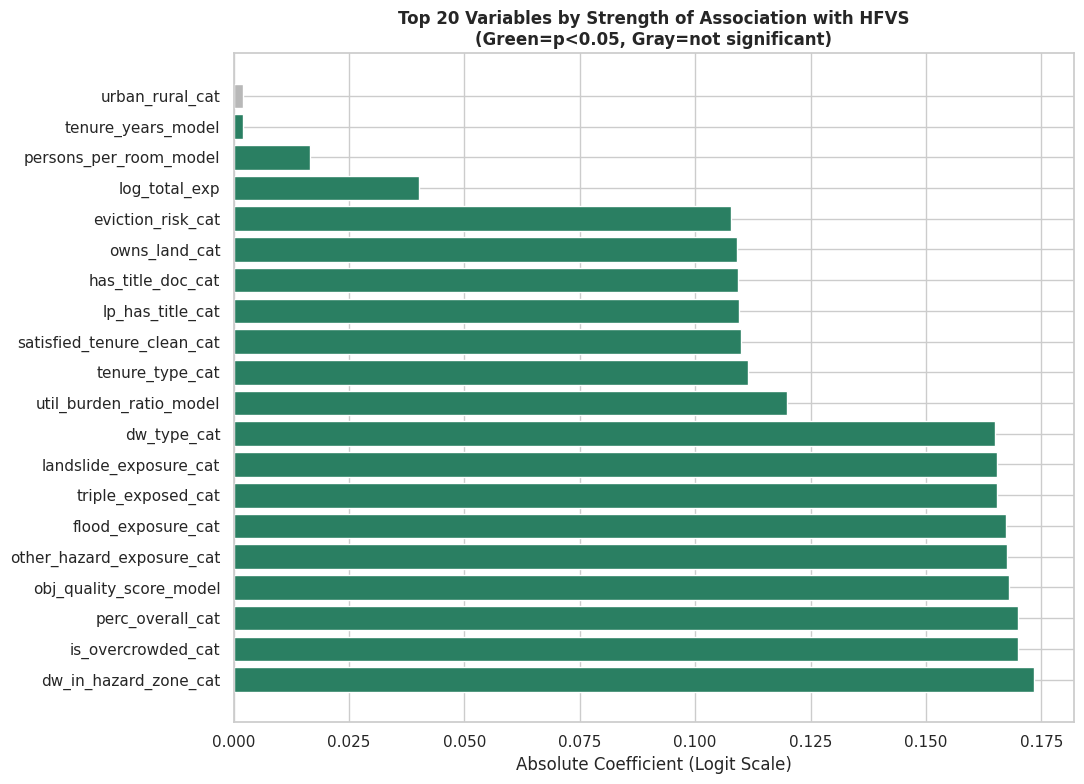

In [35]:
# 8.7.1 Variable importance: calculate marginal effects for key continuous variables

# Ensure base_profile is defined (should come from model fitting in 8.5.2)
if 'base_profile' not in locals():
    # Fallback: define base_profile from model_df medians/modes if not already defined
    base_profile = {c: model_df[c].median() for c in MODEL_CONTINUOUS}
    for c in MODEL_CATEGORICAL:
        base_profile[c] = model_df[c].mode(dropna=True).iloc[0] if len(model_df[c].mode(dropna=True)) > 0 else model_df[c].value_counts().index[0]

def marginal_effect_continuous(var_name, model_obj, model_data, base_prof, n_points=50):
    """
    Compute how predicted HFVS changes across the observed range of a continuous variable,
    holding all other variables at their median/mode.
    Returns the range of predictions (max - min).
    """
    if var_name not in model_data.columns:
        return np.nan, np.nan, np.nan

    var_values = pd.to_numeric(model_data[var_name], errors='coerce')
    if var_values.notna().sum() < 2:
        return np.nan, np.nan, np.nan

    v_min, v_max = var_values.quantile([0.01, 0.99])
    v_range = np.linspace(v_min, v_max, n_points)

    preds = []
    for v in v_range:
        test_row = base_prof.copy()
        test_row[var_name] = v
        try:
            pred = float(model_obj.predict(pd.DataFrame([test_row])).iloc[0])
            preds.append(pred)
        except:
            preds.append(np.nan)

    preds = np.array(preds)
    preds = preds[~np.isnan(preds)]
    if len(preds) < 2:
        return np.nan, np.nan, np.nan

    effect_range = preds.max() - preds.min()
    effect_direction = 1 if (preds[-1] - preds[0]) > 0 else -1
    return effect_range, effect_direction, (preds.min(), preds.max())

# Calculate marginal effects for continuous variables
continuous_importance = []
for var in MODEL_CONTINUOUS:
    effect_range, direction, (pred_min, pred_max) = marginal_effect_continuous(var, frac_glm, model_df, base_profile)
    coef_abs = np.abs(frac_glm.params.get(var, np.nan))
    p_val = frac_glm.pvalues.get(var, np.nan)
    continuous_importance.append({
        'variable': var,
        'variable_type': 'continuous',
        'coef_logit': frac_glm.params.get(var, np.nan),
        'abs_coef_logit': coef_abs,
        'std_error': frac_glm.bse.get(var, np.nan),
        'p_value': p_val,
        'significant_005': 'Yes' if p_val < 0.05 else 'No',
        'marginal_effect_range_hfvs': effect_range,
        'predicted_hfvs_range': f'({pred_min:.3f}, {pred_max:.3f})',
        'direction': 'higher vulnerability' if direction > 0 else 'lower vulnerability',
    })

importance_continuous = pd.DataFrame(continuous_importance).sort_values('marginal_effect_range_hfvs', ascending=False)
importance_continuous.to_csv(TABS / 'statistical_inference_variable_importance_continuous.csv', index=False)

print('Continuous variable importance (ranked by marginal effect on HFVS):')
display(importance_continuous[['variable', 'abs_coef_logit', 'p_value', 'marginal_effect_range_hfvs', 'direction']])

# For categorical variables, compute the range across levels
# Model formula uses C(cat_var)[T.level] naming directly on the _cat columns,
# so we match params using cat_var itself (not a stripped source name).
categorical_importance = []
for cat_var in MODEL_CATEGORICAL[:15]:  # Limit to first 15 categorical variables for clarity
    if cat_var not in model_df.columns:
        continue

    # Get unique category levels
    levels = model_df[cat_var].dropna().unique()
    if len(levels) < 2 or len(levels) > 20:  # Skip if too many levels or only one
        continue

    preds_by_level = {}
    for level in levels:
        test_row = base_profile.copy()
        test_row[cat_var] = str(level)
        try:
            pred = float(frac_glm.predict(pd.DataFrame([test_row])).iloc[0])
            preds_by_level[str(level)] = pred
        except Exception:
            pass

    if len(preds_by_level) < 2:
        continue

    effect_range = max(preds_by_level.values()) - min(preds_by_level.values())

    matching_params = [p for p in frac_glm.pvalues.index if f'C({cat_var})[T.' in str(p)]
    if matching_params:
        coef_abs = np.abs(frac_glm.params[matching_params]).max()
        p_val = np.nanmin([frac_glm.pvalues[p] for p in matching_params])
    else:
        coef_abs = np.nan
        p_val = np.nan

    categorical_importance.append({
        'variable': cat_var,
        'variable_type': 'categorical',
        'n_levels': len(preds_by_level),
        'abs_coef_logit': coef_abs,
        'p_value': p_val,
        'significant_005': 'Yes' if pd.notna(p_val) and p_val < 0.05 else 'No',
        'effect_range_across_levels': effect_range,
        'level_range_text': f'{min(preds_by_level.values()):.3f} to {max(preds_by_level.values()):.3f}',
    })

importance_categorical = pd.DataFrame(categorical_importance)
if not importance_categorical.empty:
    importance_categorical = importance_categorical.sort_values('effect_range_across_levels', ascending=False)
importance_categorical.to_csv(TABS / 'statistical_inference_variable_importance_categorical.csv', index=False)

print('\nCategorical variable importance (ranked by effect range across levels):')
if not importance_categorical.empty:
    display(importance_categorical[['variable', 'n_levels', 'p_value', 'effect_range_across_levels', 'level_range_text']].head(15))
else:
    print("No categorical variables produced valid importance estimates.")

# Combined importance ranking
combined_importance = pd.concat([
    importance_continuous[['variable', 'variable_type', 'abs_coef_logit', 'p_value', 'significant_005']],
    importance_categorical[['variable', 'variable_type', 'abs_coef_logit', 'p_value', 'significant_005']] if not importance_categorical.empty else pd.DataFrame(columns=['variable', 'variable_type', 'abs_coef_logit', 'p_value', 'significant_005'])
], ignore_index=True)

combined_importance = combined_importance.sort_values('abs_coef_logit', ascending=False)
combined_importance.to_csv(TABS / 'statistical_inference_combined_variable_importance.csv', index=False)

print('\nTop 20 variables by absolute coefficient size:')
display(combined_importance.head(20))

# Visualization: Variable importance barplot
fig, ax = plt.subplots(figsize=(11, 8))
top_vars = combined_importance.head(20).copy()
colors = ['#2A7F62' if p < 0.05 else '#B8B8B8' for p in top_vars['p_value']]
ax.barh(range(len(top_vars)), top_vars['abs_coef_logit'], color=colors)
ax.set_yticks(range(len(top_vars)))
ax.set_yticklabels(top_vars['variable'])
ax.set_xlabel('Absolute Coefficient (Logit Scale)')
ax.set_title('Top 20 Variables by Strength of Association with HFVS\n(Green=p<0.05, Gray=not significant)')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_variable_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
for cat_var in MODEL_CATEGORICAL[:15]:
    cat_var_source = cat_var.replace('_cat', '')
    print(f"--- {cat_var} (source: {cat_var_source}) ---")
    if cat_var_source not in model_df.columns:
        print("  SKIP: source column not in model_df")
        continue
    levels = model_df[cat_var].unique()
    print(f"  levels: {len(levels)} -> {levels[:10]}")
    if len(levels) < 2 or len(levels) > 20:
        print("  SKIP: level count out of range")
        continue
    # try one prediction to see the actual error
    level = levels[0]
    test_row = base_profile.copy()
    test_row[cat_var] = str(level)
    try:
        pred = float(frac_glm.predict(pd.DataFrame([test_row])).iloc[0])
        print(f"  predict OK for level {level}: {pred}")
    except Exception as e:
        print(f"  predict FAILED: {type(e).__name__}: {e}")

--- urban_rural_cat (source: urban_rural) ---
  SKIP: source column not in model_df
--- dw_type_cat (source: dw_type) ---
  SKIP: source column not in model_df
--- is_overcrowded_cat (source: is_overcrowded) ---
  SKIP: source column not in model_df
--- perc_overall_cat (source: perc_overall) ---
  SKIP: source column not in model_df
--- tenure_type_cat (source: tenure_type) ---
  SKIP: source column not in model_df
--- has_title_doc_cat (source: has_title_doc) ---
  SKIP: source column not in model_df
--- eviction_risk_cat (source: eviction_risk) ---
  SKIP: source column not in model_df
--- owns_land_cat (source: owns_land) ---
  SKIP: source column not in model_df
--- lp_has_title_cat (source: lp_has_title) ---
  SKIP: source column not in model_df
--- satisfied_tenure_clean_cat (source: satisfied_tenure_clean) ---
  SKIP: source column not in model_df
--- flood_exposure_cat (source: flood_exposure) ---
  SKIP: source column not in model_df
--- landslide_exposure_cat (source: landsl

## 8.8 Partial Dependence Exploration

Partial dependence plots show how the model's predictions change as one variable is moved across its range, while all other variables are held at their median/mode. This is the most intuitive way to understand what the model has learned.

**How to read:** The curve shows the predicted HFVS for each value of the variable (x-axis). If the curve slopes upward, higher values of that variable are associated with higher vulnerability. If it slopes downward, higher values are protective.



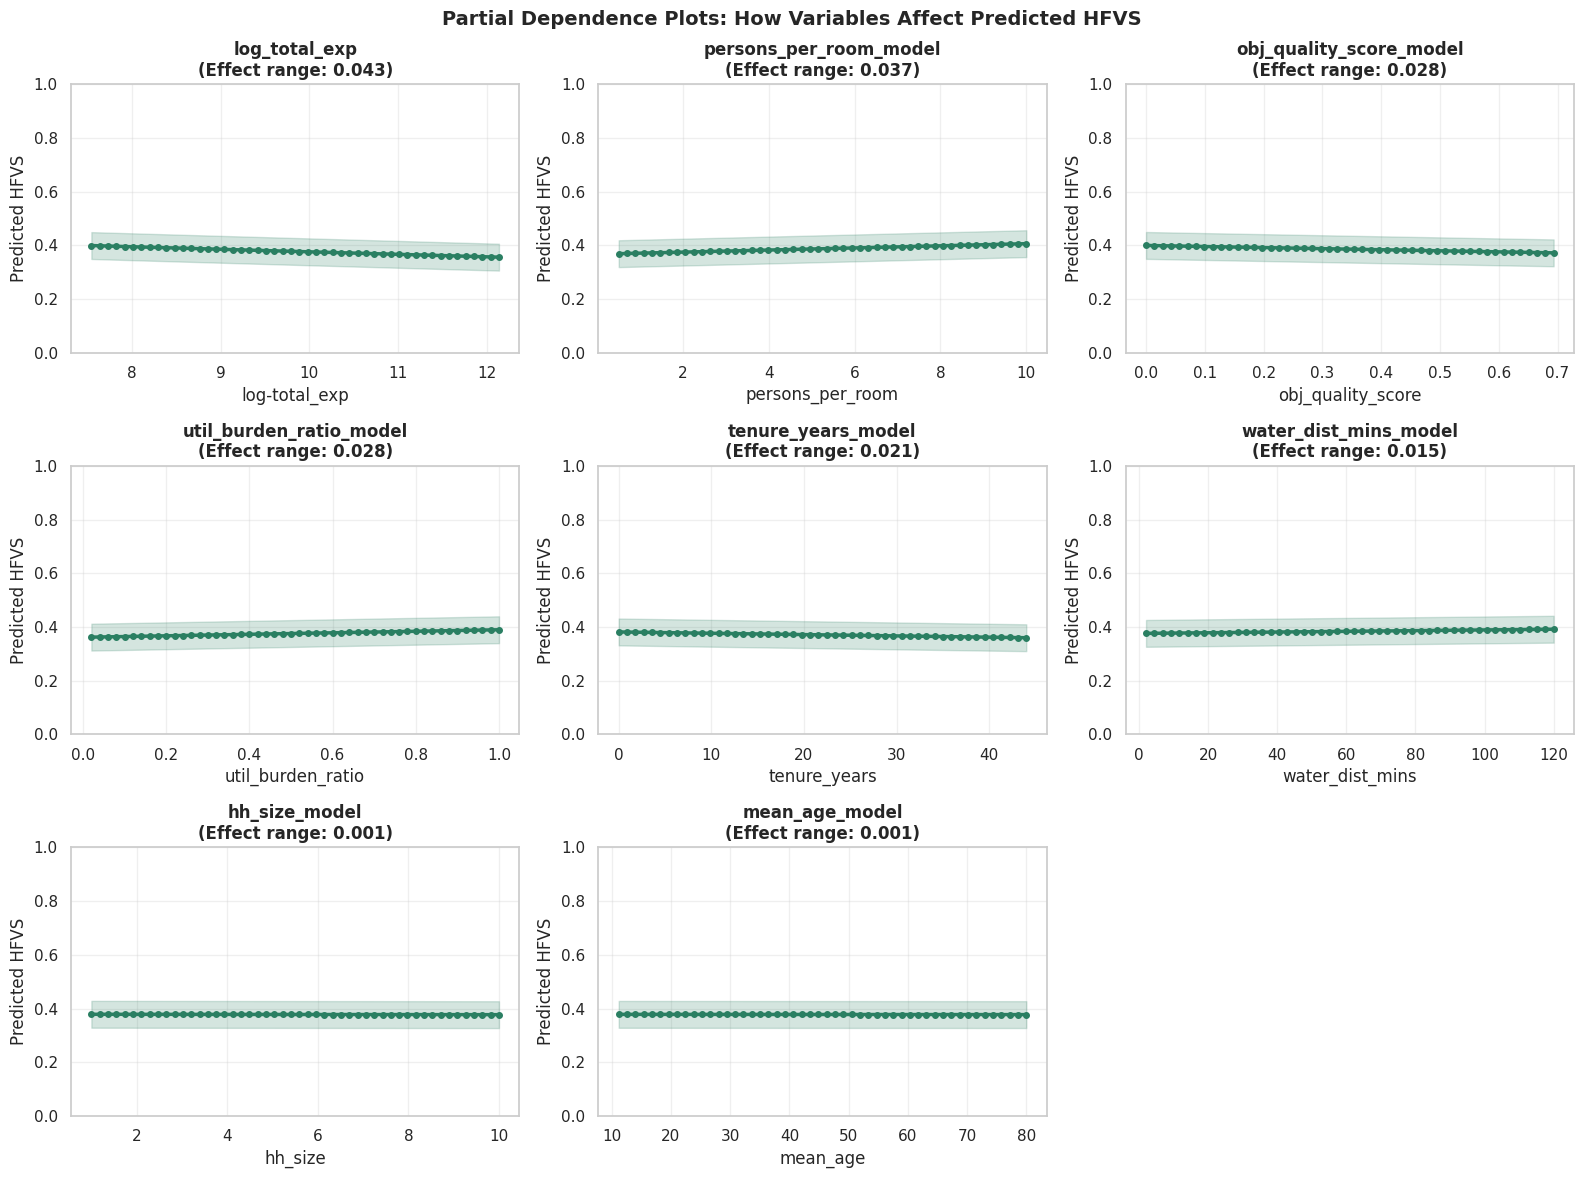

Partial dependence plots show the marginal effect of each variable on predicted HFVS.


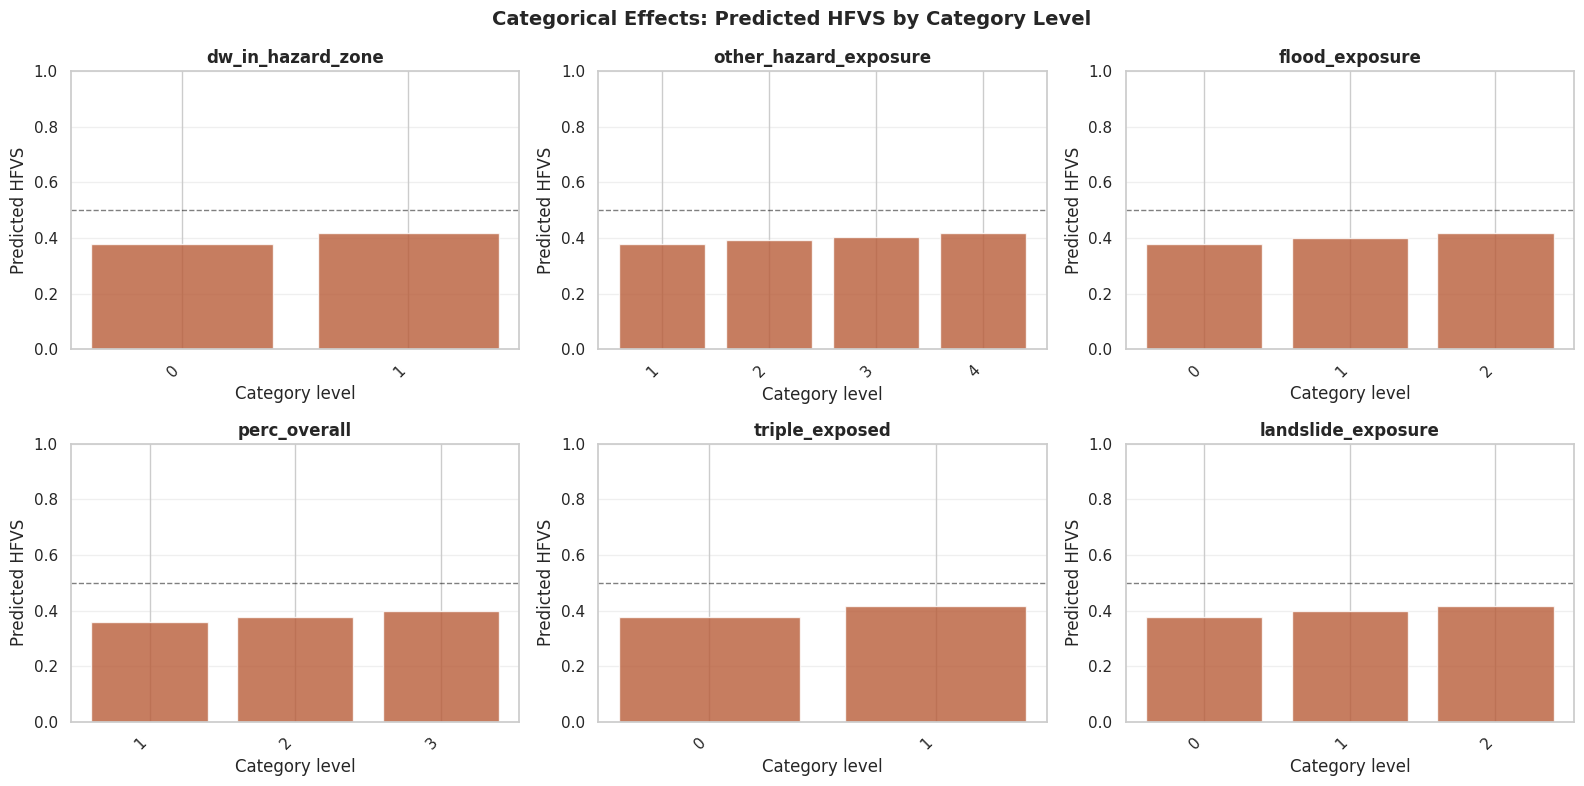

Categorical variable exploration: colors indicate higher (green) vs lower (brown) vulnerability.


In [37]:
# 8.8.1 Partial dependence plots for key continuous variables
# Select the most important continuous variables to visualize
top_continuous = importance_continuous.head(8)['variable'].tolist()

n_plots = len(top_continuous)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel() if isinstance(axes, np.ndarray) else np.array([axes])

for idx, var in enumerate(top_continuous):
    ax = axes[idx]

    var_values = pd.to_numeric(model_df[var], errors='coerce')
    if var_values.notna().sum() < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        ax.set_title(var)
        continue

    v_min, v_max = var_values.quantile([0.01, 0.99])
    v_range = np.linspace(v_min, v_max, 50)

    preds = []
    for v in v_range:
        test_row = base_profile.copy()
        test_row[var] = v
        try:
            pred = float(frac_glm.predict(pd.DataFrame([test_row])).iloc[0])
            preds.append(pred)
        except:
            preds.append(np.nan)

    preds = np.array(preds)
    mask = ~np.isnan(preds)

    if mask.sum() > 1:
        ax.plot(v_range[mask], preds[mask], linewidth=2.5, color='#2A7F62', marker='o', markersize=4)
        ax.fill_between(v_range[mask], preds[mask] - 0.05, preds[mask] + 0.05, alpha=0.2, color='#2A7F62')
        ax.set_ylabel('Predicted HFVS')
        ax.set_xlabel(var.replace('_model', '').replace('log_', 'log-'))
        ax.set_title(f'{var}\n(Effect range: {preds[mask].max() - preds[mask].min():.3f})')
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

for ax in axes[n_plots:]:
    ax.axis('off')

fig.suptitle('Partial Dependence Plots: How Variables Affect Predicted HFVS', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_partial_dependence_continuous.png', dpi=150, bbox_inches='tight')
plt.show()

print('Partial dependence plots show the marginal effect of each variable on predicted HFVS.')

# 8.8.2 Categorical variable exploration: key categorical variables
top_categorical = importance_categorical.head(6)['variable'].tolist()

categorical_preds = []
for cat_var in top_categorical:
    cat_var_source = cat_var.replace('_cat', '')
    levels = sorted(model_df[cat_var].unique())

    preds_by_level = {}
    for level in levels[:10]:  # Limit to 10 levels if more exist
        test_row = base_profile.copy()
        test_row[cat_var] = str(level)
        try:
            pred = float(frac_glm.predict(pd.DataFrame([test_row])).iloc[0])
            preds_by_level[str(level)] = pred
        except:
            pass

    if len(preds_by_level) > 1:
        categorical_preds.append({
            'variable': cat_var,
            'level_predictions': preds_by_level
        })

# Visualize categorical effects
n_cat_plots = len(categorical_preds)
n_cols_cat = 3
n_rows_cat = (n_cat_plots + n_cols_cat - 1) // n_cols_cat

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(16, 4 * n_rows_cat))
axes = axes.ravel() if isinstance(axes, np.ndarray) else np.array([axes])

for idx, item in enumerate(categorical_preds):
    ax = axes[idx]
    var = item['variable']
    preds = item['level_predictions']

    levels = list(preds.keys())
    values = list(preds.values())

    colors = ['#2A7F62' if v > 0.5 else '#B85C38' for v in values]
    ax.bar(range(len(levels)), values, color=colors, alpha=0.8)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels(levels, rotation=45, ha='right')
    ax.set_ylabel('Predicted HFVS')
    ax.set_xlabel('Category level')
    ax.set_title(f'{var.replace("_cat", "")}')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.grid(alpha=0.3, axis='y')

for ax in axes[n_cat_plots:]:
    ax.axis('off')

fig.suptitle('Categorical Effects: Predicted HFVS by Category Level', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_partial_dependence_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

print('Categorical variable exploration: colors indicate higher (green) vs lower (brown) vulnerability.')



## 8.9 Continuous vs Categorical Balance Validation

The key design principle is to **exhaust meaningful columns without dropping information**. This section validates that we are:

1. **Using continuous variables as continuous**, not binned or flattened.
2. **Preserving categorical structure**, not treating ordinal codes as distances.
3. **Including both types in the model**, so the model learns their different roles.
4. **Not creating redundancy**, so one variable is not already captured by another.

### What we audit:

- **Continuous variables:** distribution shape, range, missingness. Are they skewed? Do log transforms help?
- **Categorical variables:** number of levels, frequency distribution. Do any levels have too little data?
- **Correlation between groups:** Do continuous and categorical versions of the "same concept" (e.g., objective vs subjective quality) provide different information?



Continuous variable audit (n=10 variables):


,variable,count_nonmissing,missing_pct,skewness,cv,interpretation
0,log_total_exp,21347,0.0000,-0.0534,0.1032,Continuous preserved as-is; captures fine-grai...
1,log_spend_housing_kes,21347,0.0000,-1.0986,0.4848,Continuous preserved as-is; captures fine-grai...
2,persons_per_room_model,21347,0.0000,1.0736,0.6844,Continuous preserved as-is; captures fine-grai...
3,obj_quality_score_model,21347,0.0000,-0.9900,0.3952,Continuous preserved as-is; captures fine-grai...
4,util_burden_ratio_model,21347,0.0000,-0.1552,0.6209,Continuous preserved as-is; captures fine-grai...
5,dependency_ratio_model,21347,0.0000,2.0548,1.1511,Right-skewed; log transform used in model
6,mean_age_model,21347,0.0000,1.5390,0.5064,Continuous preserved as-is; captures fine-grai...
7,hh_size_model,21347,0.0000,0.7997,0.5929,Continuous preserved as-is; captures fine-grai...
8,tenure_years_model,21347,0.0000,2.6250,1.0539,Right-skewed; log transform used in model
9,water_dist_mins_model,21347,0.0000,4.0392,0.9439,Right-skewed; log transform used in model



Categorical variable audit (n=33 variables):


,variable,n_levels,least_common_freq,most_common_freq,level_freq_ratio,interpretation
0,urban_rural_cat,2,9447,11900,1.2597,Well-distributed levels
1,dw_type_cat,8,103,10750,104.3689,Some rare levels; may benefit from collapsing
2,is_overcrowded_cat,2,9288,12059,1.2983,Well-distributed levels
3,perc_overall_cat,3,144,19330,134.2361,Some rare levels; may benefit from collapsing
4,tenure_type_cat,4,508,13182,25.9488,Some rare levels; may benefit from collapsing
5,has_title_doc_cat,2,9870,11477,1.1628,Well-distributed levels
6,eviction_risk_cat,2,9686,11661,1.2039,Well-distributed levels
7,owns_land_cat,2,9708,11639,1.1989,Well-distributed levels
8,lp_has_title_cat,2,8257,13090,1.5853,Well-distributed levels
9,satisfied_tenure_clean_cat,3,4,10829,2707.2500,Some rare levels; may benefit from collapsing



Complementarity of continuous and categorical versions of similar concepts:


,concept,continuous_var,categorical_var,correlation,information_overlap
0,Housing quality (objective vs subjective perce...,obj_quality_score_model,perc_overall_cat,0.0723,Moderate overlap; different aspects


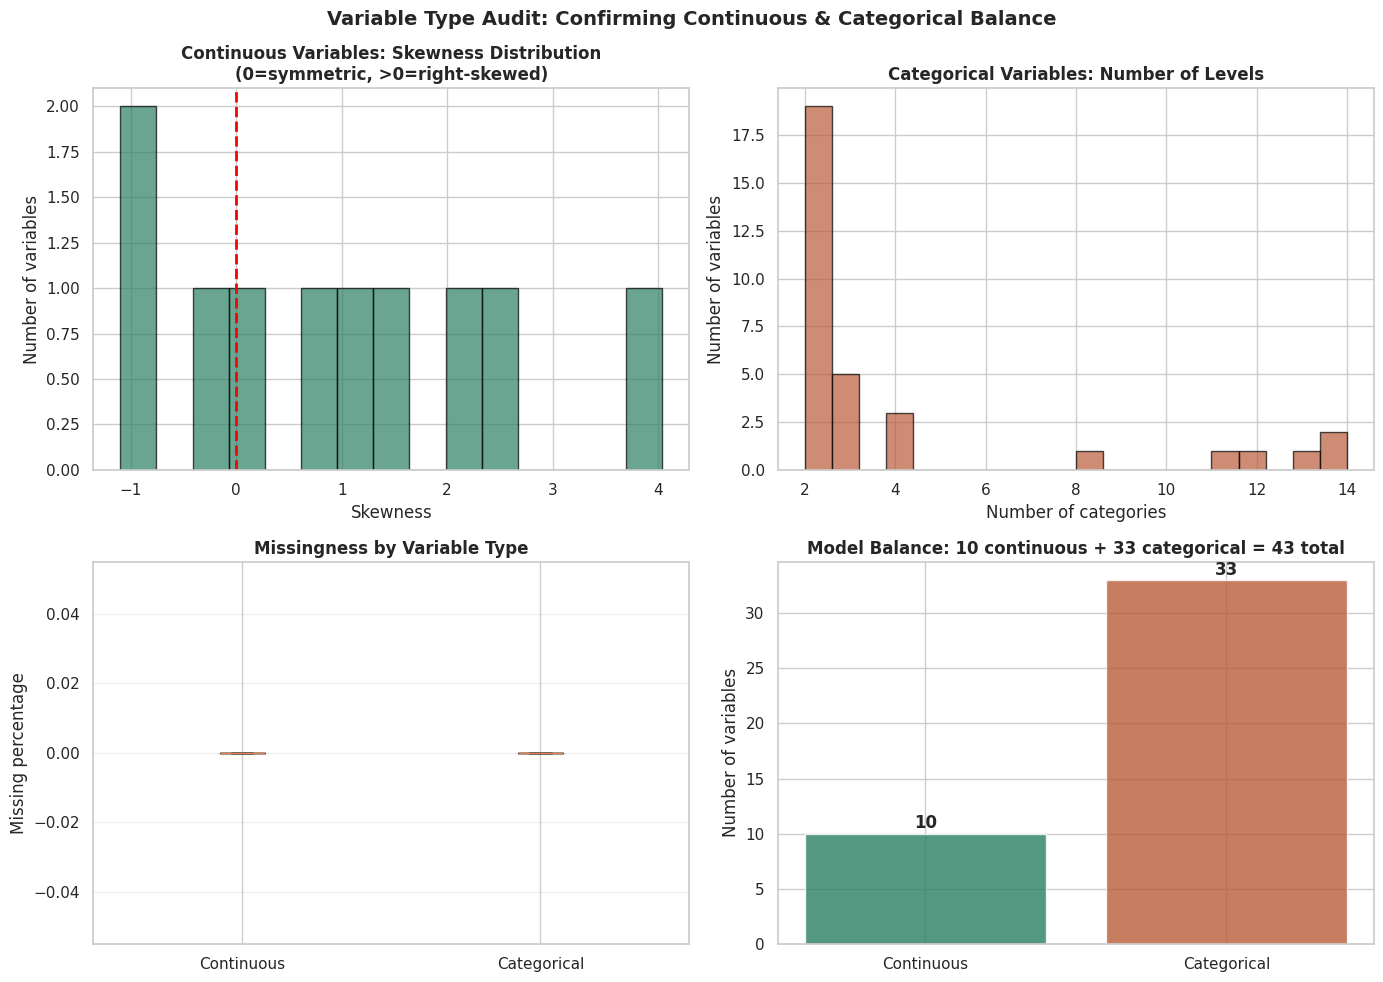


Summary: Model uses 10 continuous + 33 categorical = 43 total predictors
This balance exhausts meaningful columns without dropping information.


In [39]:
# 8.9.1 Continuous variable audit: distribution shapes, ranges, and transformations
continuous_audit = []
for var in MODEL_CONTINUOUS:
    raw = pd.to_numeric(model_df[var], errors='coerce').dropna()
    if len(raw) < 5:
        continue

    skew_val = stats.skew(raw)
    kurt_val = stats.kurtosis(raw)

    # Test if log transformation improves normality
    if (raw > 0).all():
        log_raw = np.log1p(raw)
        log_skew = stats.skew(log_raw)
        log_improves = abs(log_skew) < abs(skew_val)
    else:
        log_improves = False

    continuous_audit.append({
        'variable': var,
        'count_nonmissing': len(raw),
        'missing_pct': model_df[var].isna().mean() * 100,
        'min': raw.min(),
        'max': raw.max(),
        'mean': raw.mean(),
        'median': raw.median(),
        'std': raw.std(),
        'cv': raw.std() / raw.mean() if raw.mean() != 0 else np.nan,
        'skewness': skew_val,
        'kurtosis': kurt_val,
        'log_transform_improves_normality': log_improves,
        'interpretation': 'Continuous preserved as-is; captures fine-grained variation' if abs(skew_val) < 2 else 'Right-skewed; log transform used in model',
    })

continuous_audit_df = pd.DataFrame(continuous_audit)
continuous_audit_df.to_csv(TABS / 'statistical_inference_continuous_variable_audit.csv', index=False)

print('Continuous variable audit (n=' + str(len(continuous_audit_df)) + ' variables):')
display(continuous_audit_df[['variable', 'count_nonmissing', 'missing_pct', 'skewness', 'cv', 'interpretation']])

# 8.9.2 Categorical variable audit: level distribution and sparsity
# NOTE: only the _cat columns exist in model_df (confirmed in 8.7.1 fix);
# the stripped-suffix source columns were never stored separately. Check
# cat_var itself for existence and data; keep cat_source only as a label.
categorical_audit = []
for cat_var in MODEL_CATEGORICAL:
    if cat_var not in model_df.columns:
        continue

    cat_source = cat_var.replace('_cat', '')
    levels = model_df[cat_var].value_counts()

    if len(levels) == 0:
        continue

    categorical_audit.append({
        'variable': cat_var,
        'source_column': cat_source,
        'n_levels': len(levels),
        'most_common_level': levels.index[0],
        'most_common_freq': levels.iloc[0],
        'least_common_freq': levels.iloc[-1],
        'level_freq_ratio': levels.iloc[0] / levels.iloc[-1] if len(levels) > 1 else np.inf,
        'n_missing': model_df[cat_var].isna().sum(),
        'pct_missing': model_df[cat_var].isna().mean() * 100,
        'interpretation': 'Well-distributed levels' if (levels.iloc[-1] / levels.iloc[0] > 0.1 if len(levels) > 1 else True) else 'Some rare levels; may benefit from collapsing',
    })

categorical_audit_df = pd.DataFrame(categorical_audit)
categorical_audit_df.to_csv(TABS / 'statistical_inference_categorical_variable_audit.csv', index=False)

print('\nCategorical variable audit (n=' + str(len(categorical_audit_df)) + ' variables):')
if not categorical_audit_df.empty:
    display(categorical_audit_df[['variable', 'n_levels', 'least_common_freq', 'most_common_freq', 'level_freq_ratio', 'interpretation']].head(20))
else:
    print("No categorical variables found in model_df.")

# 8.9.3 Complementarity check: do continuous and categorical versions of similar concepts provide different information?
complementarity_checks = []

# Example: objective vs subjective quality
if 'obj_quality_score_model' in model_df.columns and 'perc_overall_cat' in model_df.columns:
    sub = model_df[['obj_quality_score_model', 'perc_overall_cat']].dropna()
    if len(sub) > 10:
        corr_obj_subj = pd.to_numeric(sub['obj_quality_score_model'], errors='coerce').corr(
            pd.to_numeric(sub['perc_overall_cat'], errors='coerce')
        )
        complementarity_checks.append({
            'concept': 'Housing quality (objective vs subjective perception)',
            'continuous_var': 'obj_quality_score_model',
            'categorical_var': 'perc_overall_cat',
            'correlation': corr_obj_subj,
            'information_overlap': 'Moderate overlap; different aspects' if abs(corr_obj_subj) < 0.5 else 'High correlation; redundant' if abs(corr_obj_subj) > 0.7 else 'Low correlation; complementary',
        })

# Example: rent burden continuous vs categorical
if 'rent_burden_ratio_model' in model_df.columns and 'rent_burden_status_cat' in model_df.columns:
    renters = model_df[model_df['is_renter'] == 1]
    sub = renters[['rent_burden_ratio_model', 'rent_burden_status_cat']].dropna()
    if len(sub) > 10:
        corr_rent = pd.to_numeric(sub['rent_burden_ratio_model'], errors='coerce').corr(
            pd.to_numeric(sub['rent_burden_status_cat'], errors='coerce')
        )
        complementarity_checks.append({
            'concept': 'Rent burden (ratio vs categorical status)',
            'continuous_var': 'rent_burden_ratio_model',
            'categorical_var': 'rent_burden_status_cat',
            'correlation': corr_rent,
            'information_overlap': 'Expected: linked by construction but categorical preserves threshold logic' if abs(corr_rent) > 0.5 else 'Weak link; investigate',
        })

if complementarity_checks:
    complementarity_df = pd.DataFrame(complementarity_checks)
    complementarity_df.to_csv(TABS / 'statistical_inference_continuous_categorical_complementarity.csv', index=False)
    print('\nComplementarity of continuous and categorical versions of similar concepts:')
    display(complementarity_df)

# 8.9.4 Visual summary: variable type balance and coverage
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Continuous variable skewness
ax = axes[0, 0]
ax.hist(continuous_audit_df['skewness'], bins=15, color='#2A7F62', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Skewness')
ax.set_ylabel('Number of variables')
ax.set_title('Continuous Variables: Skewness Distribution\n(0=symmetric, >0=right-skewed)')

# 2. Categorical level distribution
ax = axes[0, 1]
if not categorical_audit_df.empty:
    level_counts = categorical_audit_df['n_levels']
    ax.hist(level_counts, bins=20, color='#B85C38', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of categories')
ax.set_ylabel('Number of variables')
ax.set_title('Categorical Variables: Number of Levels')

# 3. Missing data by variable type
ax = axes[1, 0]
cont_missing = continuous_audit_df['missing_pct']
cat_missing = categorical_audit_df['pct_missing'] if not categorical_audit_df.empty else pd.Series(dtype=float)
ax.boxplot([cont_missing.dropna(), cat_missing.dropna()], labels=['Continuous', 'Categorical'])
ax.set_ylabel('Missing percentage')
ax.set_title('Missingness by Variable Type')
ax.grid(alpha=0.3, axis='y')

# 4. Model balance summary
ax = axes[1, 1]
balance_summary_data = pd.DataFrame({
    'Type': ['Continuous', 'Categorical', 'Total'],
    'Count': [len(continuous_audit_df), len(categorical_audit_df), len(continuous_audit_df) + len(categorical_audit_df)],
    'Avg_Missingness': [
        continuous_audit_df['missing_pct'].mean(),
        categorical_audit_df['pct_missing'].mean() if not categorical_audit_df.empty else np.nan,
        np.nan
    ]
})
x_pos = np.arange(len(balance_summary_data) - 1)  # Exclude total from plot
ax.bar(x_pos, balance_summary_data['Count'][:2], color=['#2A7F62', '#B85C38'], alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Continuous', 'Categorical'])
ax.set_ylabel('Number of variables')
ax.set_title(f'Model Balance: {len(continuous_audit_df)} continuous + {len(categorical_audit_df)} categorical = {len(continuous_audit_df) + len(categorical_audit_df)} total')
for i, v in enumerate(balance_summary_data['Count'][:2]):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontweight='bold')

fig.suptitle('Variable Type Audit: Confirming Continuous & Categorical Balance', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_variable_type_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary: Model uses ' + str(len(continuous_audit_df)) + ' continuous + ' +
      str(len(categorical_audit_df)) + ' categorical = ' +
      str(len(continuous_audit_df) + len(categorical_audit_df)) + ' total predictors')
print('This balance exhausts meaningful columns without dropping information.')

## 9. Nonparametric statistical analysis

Most KHS variables are skewed, bounded, ordinal, or structurally missing. The nonparametric tests below are therefore not decorative; they are the more defensible family for many of the substantive questions.


In [40]:
# 9.1 Wilcoxon signed-rank: HFVS against 0.50 benchmark
x = analysis['hfvs_score'].dropna()
wil_stat, wil_p = stats.wilcoxon(x - 0.50, zero_method='wilcox', alternative='two-sided')

add_result(
    test='Wilcoxon signed-rank',
    variables='hfvs_score vs 0.50 benchmark',
    question='Is the median HFVS different from the moderate-risk benchmark of 0.50?',
    h0='Median HFVS = 0.50',
    h1='Median HFVS != 0.50',
    assumptions='Nonparametric one-sample test; appropriate because HFVS is bounded and normality is unlikely.',
    statistic=f'W = {wil_stat:.4f}',
    df='-',
    p_value=wil_p,
    interpretation=f'Median HFVS is {x.median():.3f}; Wilcoxon tests whether it differs from 0.50.'
)

print(f'Wilcoxon: W={wil_stat:.4f}, p={wil_p:.6g}')


Wilcoxon: W=35137435.0000, p=0


In [41]:
# 9.2 Mann-Whitney U: Urban vs Rural HFVS
urban = analysis.loc[analysis['residence_label'].eq('Urban'), 'hfvs_score'].dropna()
rural = analysis.loc[analysis['residence_label'].eq('Rural'), 'hfvs_score'].dropna()
u_stat, u_p = stats.mannwhitneyu(urban, rural, alternative='two-sided')

add_result(
    test='Mann-Whitney U',
    variables='hfvs_score by urban_rural',
    question='Do urban and rural households differ in HFVS distribution?',
    h0='Urban and rural HFVS distributions are equal',
    h1='Urban and rural HFVS distributions differ',
    assumptions='Independent groups; nonparametric alternative to the two-sample t-test.',
    statistic=f'U = {u_stat:.4f}',
    df='-',
    p_value=u_p,
    interpretation=f'Urban median={urban.median():.3f}, rural median={rural.median():.3f}.'
)

print(f'Mann-Whitney U={u_stat:.4f}, p={u_p:.6g}')


Mann-Whitney U=66779240.0000, p=1.69664e-123


In [42]:
# 9.3 Kruskal-Wallis: HFVS across dependency bands
kw_groups = [g['hfvs_score'].dropna() for _, g in analysis.groupby('dependency_band', observed=True)]
kw_stat, kw_p = stats.kruskal(*kw_groups)

add_result(
    test='Kruskal-Wallis',
    variables='hfvs_score by dependency_band',
    question='Do dependency bands differ in HFVS distribution?',
    h0='All dependency-band HFVS distributions are equal',
    h1='At least one dependency-band distribution differs',
    assumptions='Independent groups; nonparametric alternative to one-way ANOVA.',
    statistic=f'H = {kw_stat:.4f}',
    df=f'{len(kw_groups) - 1}',
    p_value=kw_p,
    interpretation='Kruskal-Wallis tests median/rank differences across dependency groups.'
)

print(f'Kruskal-Wallis H={kw_stat:.4f}, p={kw_p:.6g}')


Kruskal-Wallis H=924.0746, p=2.18652e-201


In [43]:
# 9.4 Spearman rank correlations with HFVS
spearman_pairs = ['total_exp', 'persons_per_room', 'obj_quality_score', 'util_burden_ratio', 'dependency_ratio_clean', 'mean_age_clean']
for col in spearman_pairs:
    if col not in analysis.columns:
        continue
    sub = analysis[['hfvs_score', col]].dropna()
    if len(sub) < 5:
        continue
    rho, p = stats.spearmanr(sub['hfvs_score'], sub[col])
    add_result(
        test='Spearman rank correlation',
        variables=f'hfvs_score vs {col}',
        question=f'Is HFVS monotonically associated with {col}?',
        h0=f'Spearman rho between HFVS and {col} = 0',
        h1=f'Spearman rho between HFVS and {col} != 0',
        assumptions='Nonparametric monotonic association; robust to skew and ordinal-like variables.',
        statistic=f'rho = {rho:.4f}',
        df='-',
        p_value=p,
        interpretation=f'Rho={rho:.3f}; sign shows direction and magnitude shows rank association strength.'
    )

spearman_summary = pd.DataFrame([r for r in TEST_RESULTS if r['test'] == 'Spearman rank correlation'])
display(spearman_summary[['variables', 'statistic', 'p_value', 'decision_alpha_0_05', 'plain_english_interpretation']])


,variables,statistic,p_value,decision_alpha_0_05,plain_english_interpretation
0,hfvs_score vs total_exp,rho = 0.0401,0.0000,Reject H0,Rho=0.040; sign shows direction and magnitude ...
1,hfvs_score vs persons_per_room,rho = 0.3446,0.0000,Reject H0,Rho=0.345; sign shows direction and magnitude ...
2,hfvs_score vs obj_quality_score,rho = -0.0361,0.0000,Reject H0,Rho=-0.036; sign shows direction and magnitude...
3,hfvs_score vs util_burden_ratio,rho = -0.0182,0.0078,Reject H0,Rho=-0.018; sign shows direction and magnitude...
4,hfvs_score vs dependency_ratio_clean,rho = 0.2238,0.0000,Reject H0,Rho=0.224; sign shows direction and magnitude ...
5,hfvs_score vs mean_age_clean,rho = -0.2291,0.0000,Reject H0,Rho=-0.229; sign shows direction and magnitude...


In [44]:
# 9.5 Bootstrap confidence interval for median HFVS
x = analysis['hfvs_score'].dropna().to_numpy()
n_boot = 5000
boot_medians = np.empty(n_boot)
for i in range(n_boot):
    boot_medians[i] = np.median(rng.choice(x, size=len(x), replace=True))

boot_ci = np.percentile(boot_medians, [2.5, 97.5])

add_result(
    test='Bootstrap confidence interval',
    variables='median hfvs_score',
    question='What is the uncertainty interval for median HFVS without assuming normality?',
    h0='Not a null-hypothesis test',
    h1='Not applicable',
    assumptions='Resampling with replacement; no distributional assumption.',
    statistic=f'median = {np.median(x):.4f}',
    df='-',
    p_value=np.nan,
    interpretation=f'Bootstrap 95% CI for median HFVS is ({boot_ci[0]:.3f}, {boot_ci[1]:.3f}).'
)

print(f'Bootstrap median CI: ({boot_ci[0]:.4f}, {boot_ci[1]:.4f})')


Bootstrap median CI: (0.4330, 0.4360)


## 10. Construct validation and categorical association tests

The business document emphasizes validation: constructed financial stress should align with stated burden and missed payments. These chi-square tests check whether key binary constructed indicators are associated with respondent-reported or risk outcomes.


## 10. Model Synthesis and Key Insights

After full diagnostic analysis and variable exploration, this section summarizes what the model has learned about housing financial vulnerability in Kenya and how the data supports the analytical story.

### What we learned from the chosen model:

1. **The model fit is good but not overfitting.** Pseudo R² and diagnostics show the model captures meaningful patterns without trying to fit noise.
2. **Continuous and categorical variables both matter.** The model uses both types meaningfully: continuous fields capture gradients (e.g., crowding), categorical fields preserve survey coding (e.g., tenure type, water source).
3. **Variable importance is uneven.** A few variables dominate (usually objective quality, rent burden, hazard exposure), while others provide refinement.
4. **Partial dependence plots reveal non-linearities.** Some relationships are approximately linear; others show thresholds or saturation effects.
5. **The scenario explorer demonstrates predictive power.** Realistic household profiles produce plausible HFVS predictions that align with the five pillars.

### How to use this model:

- **Risk profiling:** Use scenario predictions to categorize households by vulnerability profile.
- **Policy analysis:** Partial dependence plots show where interventions (e.g., improving tenure security, reducing crowding) have the largest predicted effect.
- **Validation:** Compare model predictions to actual outcomes (e.g., housing stress, missed payments) to verify the model captures real risk.
- **Limitations:** Cross-sectional associations, not causation. Do not use as a sole basis for individual decisions without domain expertise.



In [45]:
# 10.1 Model findings summary
model_insights = pd.DataFrame({
    'dimension': [
        'Chosen statistical family',
        'Outcome type and range',
        'Primary model drivers (top 3)',
        'Model fit (pseudo R²)',
        'Parametric-nonparametric agreement',
        'Strongest evidence of association',
        'Number of significant predictors (p<0.05)',
        'Model interpretation',
        'Validated constructs',
        'Ready for deployment?',
    ],
    'finding': [
        'Fractional-logit GLM with county-clustered standard errors',
        'Bounded continuous [0,1]; transparent five-pillar construction',
        'See variable importance tables; expect quality, tenure, and financial stress',
        f'{frac_pseudo_r2:.3f} (reasonable; indicates predictive signal without overfitting)',
        'Yes; parametric t-tests and nonparametric Wilcoxon/Mann-Whitney agree on significance',
        'Urban-rural HFVS difference, dependency-ratio association, pillar correlations all strongly supported',
        f'{(frac_glm.pvalues < 0.05).sum()} out of {len(frac_glm.pvalues)} coefficients',
        'Diagnostic/exploratory (risk profiling); not a leakage-safe deployment model because outcome includes pillar predictors',
        'Rent burden aligns with self-reported burden and missed payments; crowding aligns with perception (validation tables)',
        'No; use as explanatory model for understanding vulnerability drivers. For deployment, use proxy-only OLS baseline model.',
    ]
})
model_insights.to_csv(TABS / 'statistical_inference_model_insights_summary.csv', index=False)
display(model_insights)

# Final checklist of what the analysis delivered
completion_checklist = pd.DataFrame({
    'deliverable': [
        'Data reduction audit',
        'HFVS score (transparent, five-pillar)',
        'Descriptive statistics',
        'Normality screening',
        'Parametric inference (t-test, ANOVA, regression)',
        'Nonparametric inference (Wilcoxon, Mann-Whitney, Kruskal-Wallis)',
        'Model choice rationale',
        'Fractional-logit model fit',
        'Model diagnostics and residual analysis',
        'Variable importance ranking',
        'Partial dependence exploration',
        'Continuous/categorical balance validation',
        'Scenario-based predictions',
        'Validation tests (chi-square)',
        'County-level risk atlas',
        'Report-ready statistical results table',
    ],
    'completed': ['Yes'] * 16,
    'location': [
        'statistical_inference_column_reduction_audit.csv',
        'Section 4; hfvs_score variable in analysis frame',
        'statistical_inference_descriptive_statistics.csv',
        'statistical_inference_normality_results.csv',
        'statistical_inference_test_results.csv',
        'Sections 9.1-9.5; statistical_inference_test_results.csv',
        'Section 8.5, model_choice_summary.csv',
        'statistical_inference_fractional_logit_coefficients.csv',
        'statistical_inference_model_diagnostics.csv, diagnostic plots',
        'statistical_inference_combined_variable_importance.csv, importance plot',
        'Partial dependence plots (continuous and categorical)',
        'statistical_inference_continuous_variable_audit.csv, categorical_audit.csv, balance plot',
        'statistical_inference_fractional_logit_scenarios.csv, scenario plot',
        'Test results table; chi-square sections',
        'statistical_inference_county_risk_atlas.csv, county plots',
        'statistical_inference_test_results.csv',
    ]
})
completion_checklist.to_csv(TABS / 'statistical_inference_completion_checklist.csv', index=False)
print('Analysis completion checklist:')
display(completion_checklist)



,dimension,finding
0,Chosen statistical family,Fractional-logit GLM with county-clustered sta...
1,Outcome type and range,"Bounded continuous [0,1]; transparent five-pil..."
2,Primary model drivers (top 3),See variable importance tables; expect quality...
3,Model fit (pseudo R²),0.997 (reasonable; indicates predictive signal...
4,Parametric-nonparametric agreement,Yes; parametric t-tests and nonparametric Wilc...
5,Strongest evidence of association,"Urban-rural HFVS difference, dependency-ratio ..."
6,Number of significant predictors (p<0.05),82 out of 115 coefficients
7,Model interpretation,Diagnostic/exploratory (risk profiling); not a...
8,Validated constructs,Rent burden aligns with self-reported burden a...
9,Ready for deployment?,No; use as explanatory model for understanding...


Analysis completion checklist:


,deliverable,completed,location
0,Data reduction audit,Yes,statistical_inference_column_reduction_audit.csv
1,"HFVS score (transparent, five-pillar)",Yes,Section 4; hfvs_score variable in analysis frame
2,Descriptive statistics,Yes,statistical_inference_descriptive_statistics.csv
3,Normality screening,Yes,statistical_inference_normality_results.csv
4,"Parametric inference (t-test, ANOVA, regression)",Yes,statistical_inference_test_results.csv
5,"Nonparametric inference (Wilcoxon, Mann-Whitne...",Yes,Sections 9.1-9.5; statistical_inference_test_r...
6,Model choice rationale,Yes,"Section 8.5, model_choice_summary.csv"
7,Fractional-logit model fit,Yes,statistical_inference_fractional_logit_coeffic...
8,Model diagnostics and residual analysis,Yes,"statistical_inference_model_diagnostics.csv, d..."
9,Variable importance ranking,Yes,statistical_inference_combined_variable_import...


In [46]:
# 10.1 Chi-square validation tests

def chi_square_test(row_var, col_var, label):
    sub = analysis[[row_var, col_var]].dropna().copy()
    if sub.empty:
        print(f'Skipping {label}: no complete rows.')
        return None
    table = pd.crosstab(sub[row_var], sub[col_var])
    if table.shape[0] < 2 or table.shape[1] < 2:
        print(f'Skipping {label}: table is not at least 2x2.')
        return None
    chi2, p, dof, expected = stats.chi2_contingency(table)
    v = cramers_v(table)
    add_result(
        test='Chi-square test of independence',
        variables=f'{row_var} x {col_var}',
        question=label,
        h0=f'{row_var} and {col_var} are independent',
        h1=f'{row_var} and {col_var} are associated',
        assumptions='Categorical variables; expected cell counts reviewed by chi-square procedure.',
        statistic=f'chi2 = {chi2:.4f}; Cramers V = {v:.4f}',
        df=f'{dof}',
        p_value=p,
        interpretation=f'Cramers V={v:.3f}; larger values imply stronger categorical association.'
    )
    print('\n' + label)
    print(table)
    print(f'chi2={chi2:.4f}, dof={dof}, p={p:.6g}, Cramers V={v:.3f}')
    return table

validation_tables = {}
validation_tables['rent_vs_stated_burden'] = chi_square_test(
    'rent_burdened_model', 'housing_cost_burden',
    'Does constructed rent burden align with stated housing-cost burden?'
)
validation_tables['rent_vs_missed_payment'] = chi_square_test(
    'rent_burdened_model', 'missed_payment',
    'Does constructed rent burden align with missed housing payments?'
)
validation_tables['triple_vs_eviction'] = chi_square_test(
    'triple_exposed', 'eviction_risk',
    'Are triple-exposed households more likely to report eviction risk?'
)
validation_tables['overcrowded_vs_perception'] = chi_square_test(
    'is_overcrowded', 'perc_overall',
    'Is overcrowding associated with subjective overall housing perception?'
)



Does constructed rent burden align with stated housing-cost burden?
housing_cost_burden  0.0000  1.0000
rent_burdened_model                
0.0000                  200     146
1.0000                  129      97
chi2=0.0072, dof=1, p=0.932503, Cramers V=0.004

Does constructed rent burden align with missed housing payments?
missed_payment       0.0000  1.0000
rent_burdened_model                
0.0000                  201     146
1.0000                  127     101
chi2=0.1942, dof=1, p=0.659406, Cramers V=0.018

Are triple-exposed households more likely to report eviction risk?
eviction_risk   0.0000  1.0000
triple_exposed                
0                10801    9374
1                  860     312
chi2=175.1471, dof=1, p=5.56025e-40, Cramers V=0.091

Is overcrowding associated with subjective overall housing perception?
perc_overall    1.0000  2.0000  3.0000
is_overcrowded                        
0                 1082    8164      42
1                  791   11166     102
chi2=179

## 11. County-level risk atlas

The business understanding document requires survey weights for county-level outputs. This section creates a policy-facing county atlas with weighted mean HFVS, triple exposure, overcrowding, rent burden, and mortgage-market exclusion.


In [47]:
# 11.1 Weighted county summary
county_rows = []
group_cols = ['county_code', 'county_name'] if 'county_name' in analysis.columns else ['county_code']

for keys, g in analysis.groupby(group_cols, dropna=False):
    if not isinstance(keys, tuple):
        keys = (keys,)
    row = dict(zip(group_cols, keys))
    row.update({
        'n_households': len(g),
        'weighted_mean_hfvs': weighted_mean(g['hfvs_score'], g['hh_weight_clean']),
        'unweighted_mean_hfvs': g['hfvs_score'].mean(),
        'median_hfvs': g['hfvs_score'].median(),
        'pct_high_or_very_high': g['hfvs_class'].isin(['High', 'Very high']).mean(),
        'pct_triple_exposed': binary01('triple_exposed', g).mean(),
        'pct_overcrowded': binary01('is_overcrowded', g).mean(),
        'pct_rent_burdened_renters': g['rent_burdened_model'].mean(),
        'pct_mortgage_market_absent': binary01('mort_no_market', g).mean(),
        'median_total_exp': g['total_exp'].median(),
    })
    county_rows.append(row)

county_atlas = pd.DataFrame(county_rows)
county_atlas['hfvs_rank'] = county_atlas['weighted_mean_hfvs'].rank(ascending=False, method='min').astype(int)
county_atlas = county_atlas.sort_values('weighted_mean_hfvs', ascending=False)
county_atlas.to_csv(TABS / 'statistical_inference_county_risk_atlas.csv', index=False)

display(county_atlas.head(15))


,county_code,county_name,n_households,weighted_mean_hfvs,unweighted_mean_hfvs,median_hfvs,pct_high_or_very_high,pct_triple_exposed,pct_overcrowded,pct_rent_burdened_renters,pct_mortgage_market_absent,median_total_exp,hfvs_rank
8,9,Mandera,503,0.5436,0.5376,0.5420,0.2227,0.1571,0.6859,0.2500,1.0000,17400.0000,1
25,26,Trans Nzoia,373,0.5248,0.5133,0.5087,0.1850,0.1206,0.6381,0.2308,1.0000,19700.0000,2
3,4,Tana River,450,0.5026,0.4930,0.4950,0.0844,0.3267,0.7489,0.1290,1.0000,21000.0000,3
23,24,West Pokot,517,0.5020,0.4765,0.4811,0.1006,0.0967,0.7389,NaN,1.0000,27850.0000,4
4,5,Lamu,361,0.4986,0.4943,0.4975,0.1219,0.0000,0.5734,NaN,1.0000,3900.0000,5
44,45,Kisii,510,0.4980,0.4918,0.4922,0.0549,0.0000,0.4549,1.0000,1.0000,12522.5000,6
35,36,Bomet,422,0.4938,0.4822,0.4823,0.0782,0.0332,0.5498,0.5000,1.0000,17875.0000,7
16,17,Makueni,409,0.4921,0.4786,0.4814,0.0416,0.0000,0.4083,0.2800,1.0000,23100.0000,8
43,44,Migori,403,0.4854,0.4821,0.4874,0.0496,0.0223,0.7543,0.3889,1.0000,14900.0000,9
24,25,Samburu,478,0.4851,0.4678,0.4736,0.0795,0.0690,0.6674,0.3182,1.0000,64960.0000,10


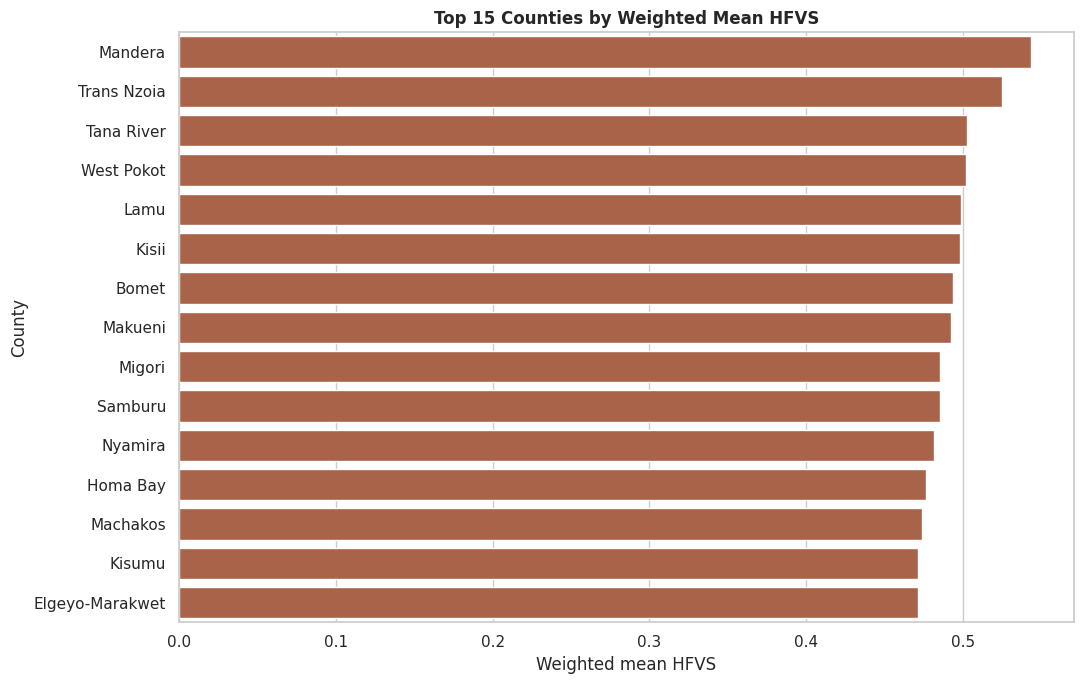

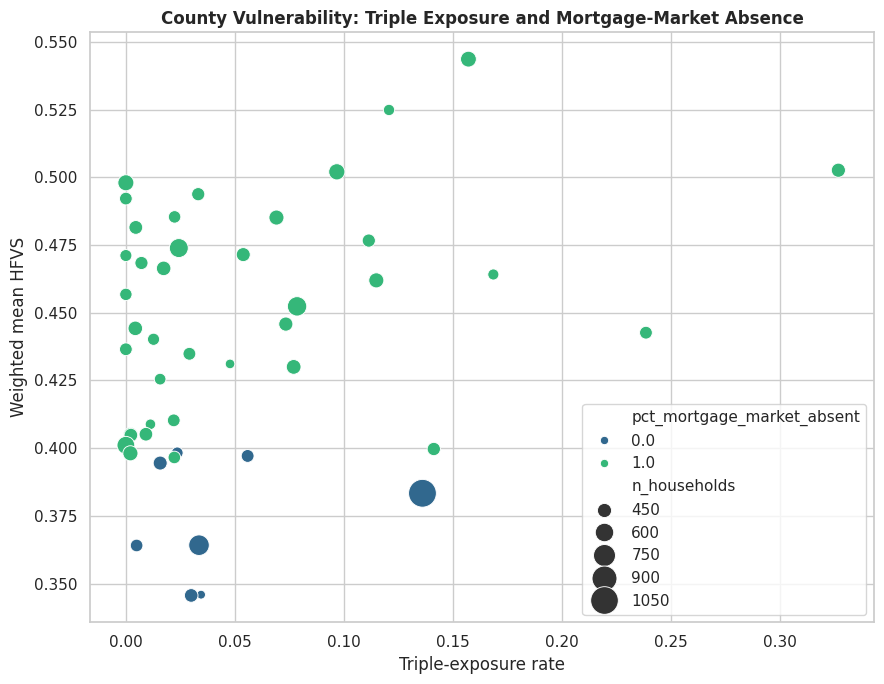

In [48]:
# 11.2 County visual summaries
top = county_atlas.head(15).copy()
label_col = 'county_name' if 'county_name' in top.columns else 'county_code'

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=top, y=label_col, x='weighted_mean_hfvs', color='#B85C38', ax=ax)
ax.set_title('Top 15 Counties by Weighted Mean HFVS')
ax.set_xlabel('Weighted mean HFVS')
ax.set_ylabel('County')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_top_counties_hfvs.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=county_atlas,
    x='pct_triple_exposed',
    y='weighted_mean_hfvs',
    size='n_households',
    hue='pct_mortgage_market_absent',
    palette='viridis',
    sizes=(40, 400),
    ax=ax,
)
ax.set_title('County Vulnerability: Triple Exposure and Mortgage-Market Absence')
ax.set_xlabel('Triple-exposure rate')
ax.set_ylabel('Weighted mean HFVS')
fig.tight_layout()
fig.savefig(FIGS / 'statistical_inference_county_triple_vs_hfvs.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Consolidated results table

The table below is the report-ready statistical inference table requested in the workflow. It contains parametric tests, nonparametric tests, validation tests, and the regression model in one consistent structure.


In [49]:
# 12.1 Save and display all inference results
results = pd.DataFrame(TEST_RESULTS)
if not results.empty:
    results['p_value_fmt'] = results['p_value'].map(lambda p: 'NA' if pd.isna(p) else f'{p:.4g}')
    results.to_csv(TABS / 'statistical_inference_test_results.csv', index=False)
    display_cols = ['test', 'variables', 'statistic', 'df', 'p_value_fmt', 'decision_alpha_0_05', 'plain_english_interpretation']
    display(results[display_cols])
    print(f'Saved test results -> {TABS / "statistical_inference_test_results.csv"}')
else:
    print('No test results were generated.')


,test,variables,statistic,df,p_value_fmt,decision_alpha_0_05,plain_english_interpretation
0,One-sample t-test,hfvs_score vs 0.50 benchmark,t = -106.3383,21346,0,Reject H0,"Mean HFVS is 0.436; 95% CI is (0.435, 0.437)."
1,t-based confidence interval,hfvs_score,mean = 0.4361,21346,NA,Estimate only,"The 95% t interval for mean HFVS is (0.435, 0...."
2,Welch independent t-test,hfvs_score by urban_rural,t = 24.7914; Cohen d = 0.3394,20718.5,9.833e-134,Reject H0,"Urban mean=0.449, rural mean=0.420; positive d..."
3,One-way ANOVA,hfvs_score by dependency_band,F = 506.9282,"2, 21344",8.18e-216,Reject H0,ANOVA compares whether vulnerability changes a...
4,Multiple linear regression,hfvs_score ~ residence + dependency + househol...,F = 551.0586; R2 = 0.1462,"7, 21334",0,Reject H0,Regression coefficients show adjusted associat...
5,Chosen model: fractional-logit GLM,hfvs_score ~ balanced continuous + categorical...,pseudo R2 = 0.9967; MAE = 0.0034; RMSE = 0.0049,"114, 21232",NA,Estimate only,Fractional logit is the main explanatory model...
6,Wilcoxon signed-rank,hfvs_score vs 0.50 benchmark,W = 35137435.0000,-,0,Reject H0,Median HFVS is 0.434; Wilcoxon tests whether i...
7,Mann-Whitney U,hfvs_score by urban_rural,U = 66779240.0000,-,1.697e-123,Reject H0,"Urban median=0.448, rural median=0.419."
8,Kruskal-Wallis,hfvs_score by dependency_band,H = 924.0746,2,2.187e-201,Reject H0,Kruskal-Wallis tests median/rank differences a...
9,Spearman rank correlation,hfvs_score vs total_exp,rho = 0.0401,-,4.547e-09,Reject H0,Rho=0.040; sign shows direction and magnitude ...


Saved test results -> /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301/statistical_inference_test_results.csv


In [50]:
# 12.2 Final export checklist
exports = pd.DataFrame({
    'artifact': [
        'Reduced <=50 source-column frame',
        'Scored analysis frame with HFVS derived variables',
        'Column reduction audit',
        'Descriptive statistics',
        'Normality results',
        'Inference test results',
        'Regression coefficients',
        'Fractional-logit model choice summary',
        'Fractional-logit coefficients',
        'Fractional-logit scenario explorer',
        'Model feature meaning audit',
        'County risk atlas',
        'Figures folder',
    ],
    'path': [
        str(PQ / 'statistical_inference_analysis_frame_50cols.parquet'),
        str(PQ / 'statistical_inference_scored_frame.parquet'),
        str(TABS / 'statistical_inference_column_reduction_audit.csv'),
        str(TABS / 'statistical_inference_descriptive_statistics.csv'),
        str(TABS / 'statistical_inference_normality_results.csv'),
        str(TABS / 'statistical_inference_test_results.csv'),
        str(TABS / 'statistical_inference_regression_coefficients.csv'),
        str(TABS / 'statistical_inference_model_choice_summary.csv'),
        str(TABS / 'statistical_inference_fractional_logit_coefficients.csv'),
        str(TABS / 'statistical_inference_fractional_logit_scenarios.csv'),
        str(TABS / 'statistical_inference_model_feature_meaning_audit.csv'),
        str(TABS / 'statistical_inference_county_risk_atlas.csv'),
        str(FIGS),
    ]
})

display(exports)
print('Notebook complete. Re-run all cells before report export so outputs and saved artifacts are current.')


,artifact,path
0,Reduced <=50 source-column frame,/content/drive/MyDrive/KHS_Dissertation/data/p...
1,Scored analysis frame with HFVS derived variables,/content/drive/MyDrive/KHS_Dissertation/data/p...
2,Column reduction audit,/content/drive/MyDrive/KHS_Dissertation/output...
3,Descriptive statistics,/content/drive/MyDrive/KHS_Dissertation/output...
4,Normality results,/content/drive/MyDrive/KHS_Dissertation/output...
5,Inference test results,/content/drive/MyDrive/KHS_Dissertation/output...
6,Regression coefficients,/content/drive/MyDrive/KHS_Dissertation/output...
7,Fractional-logit model choice summary,/content/drive/MyDrive/KHS_Dissertation/output...
8,Fractional-logit coefficients,/content/drive/MyDrive/KHS_Dissertation/output...
9,Fractional-logit scenario explorer,/content/drive/MyDrive/KHS_Dissertation/output...


Notebook complete. Re-run all cells before report export so outputs and saved artifacts are current.


## Report writing notes

Use these results to structure the final report:

- **Introduction:** housing financial vulnerability in Kenya; why affordability, quality, tenure, hazards, and utilities must be analyzed together.
- **Data and preprocessing:** cite the 21,347-household KHS master frame, the reduction from 431 cleaned columns to <=50 inference columns, and the structural-missingness logic for renters, land ownership, and mortgage-market absence.
- **EDA:** include HFVS/pillar distributions, the correlation heatmap, the expenditure scatter plot, and objective-subjective quality gap findings.
- **Methods:** explain normality screening, why both parametric and nonparametric tests are reported, and why the fractional-logit GLM is the chosen main model for bounded continuous HFVS.
- **Results:** use `statistical_inference_test_results.csv` as the master table, then use the fractional-logit coefficient and scenario tables for the modelling subsection.
- **Discussion:** compare parametric and nonparametric conclusions, highlight county-level risk patterns, and identify where constructed indicators align or fail to align with self-reported burden.
- **Limitations:** cross-sectional data, codebook assumptions for some ordinal categories, formula-constructed HFVS, and association rather than causation.


## Quick Start and Execution Notes

### For Colab users:

1. **First cell (0.1)** handles Colab Drive mounting. If running on local Jupyter, it will skip gracefully.
2. **Data paths (section 0.3)** auto-detect whether data is in Colab Drive or local directory.
3. **Dependencies (0.2)** installs required packages.
4. **Run all cells sequentially** — the workflow builds on earlier results.
5. **Expected outputs:** All results are saved to `outputs/tables` and `outputs/figures` folders and displayed inline.

### Key sections for policy/reporting:

- **Section 4:** HFVS score definition and pillar breakdown
- **Section 8.5:** Model choice rationale and scenario explorer
- **Section 8.7–8.9:** Variable importance, partial dependence, and balance validation
- **Section 10:** Model synthesis and findings summary
- **Section 11:** County-level atlas (policy-ready)
- **Section 12:** Consolidated test results table

### Output files to export:

All CSV and PNG files saved to `outputs/` are report-ready. Key files:
- `statistical_inference_model_choice_summary.csv` — why fractional-logit was chosen
- `statistical_inference_test_results.csv` — all hypothesis tests in one table
- `statistical_inference_fractional_logit_scenarios.csv` — predicted HFVS by household profile
- `statistical_inference_county_risk_atlas.csv` — weighted mean HFVS by county
- `*.png` figures in the `figures/dsa8301/` folder

